In [ ]:
!pip install -q "numpy==1.26.4"

In [ ]:
!pip install "transformer_lens==2.17.0"

In [ ]:
import os
import json
import gc
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer
from pathlib import Path
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
import logging

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", message=".*Glyph.*missing.*")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

PALETTE = {
    "correction": "#e74c3c",
    "random":     "#95a5a6",
    "before":     "#3498db",
    "on":         "#e67e22",
    "hard":       "#9b59b6",
    "easy":       "#27ae60",
    "dark":       "#2c3e50",
}

plt.rcParams.update({
    "figure.dpi":         130,
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "--",
})

In [ ]:
# ── font setup ─────────────────────────────────────────────────

def setup_fonts():
    """Set up fonts with broad Unicode coverage."""
    import subprocess
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
    warnings.filterwarnings("ignore", message=".*Glyph.*missing from font.*")
    warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

    packages = ["fonts-noto-cjk", "fonts-noto-color-emoji"]
    for pkg in packages:
        fonts = [f for f in fm.findSystemFonts()
                 if "noto" in f.lower()]
        if not fonts:
            subprocess.run(["apt-get", "install", "-y", "-q", pkg],
                           capture_output=True)

    import matplotlib
    cache_dir = matplotlib.get_cachedir()
    for f in os.listdir(cache_dir):
        if f.endswith(".json") or f.endswith(".cache"):
            try:
                os.remove(os.path.join(cache_dir, f))
            except Exception:
                pass
    fm._load_fontmanager(try_read_cache=False)

    noto_fonts = [f for f in fm.findSystemFonts() if "noto" in f.lower()]
    font_names = ["DejaVu Sans"]
    for fp in noto_fonts:
        try:
            name = fm.FontProperties(fname=fp).get_name()
            fm.fontManager.addfont(fp)
            if name not in font_names:
                font_names.append(name)
        except Exception:
            pass

    plt.rcParams["font.family"] = font_names
    print(f"Fonts: {font_names[:4]}")

setup_fonts()

Fonts: ['DejaVu Sans', 'Noto Sans Mono', 'Noto Mono']


In [ ]:
# ── configuration ───────────────────────────────────────────────
CLASSIFIED_FILE = '/kaggle/input/datasets/svvikhlyantseva/classified-corrections-expanded-context/classified_corrections_expanded_context.json'
SOURCE_FILE     = '/kaggle/input/datasets/svvikhlyantseva/merged-results/merged_results.json'
OUTPUT_DIR      = '/kaggle/working/logit_lens_output'
MODEL_NAME      = 'Qwen/Qwen3-8B'

MAX_TOKENS   = 256   # prompt truncation — keeps the end (closest to the marker)
N_TOP_TOKENS = 5     # top-k tokens to report per layer
RANDOM_SEED  = 42
# ────────────────────────────────────────────────────────────────

np.random.seed(RANDOM_SEED)
Path(OUTPUT_DIR).mkdir(exist_ok=True)

In [ ]:
# ── 1. DATA LOADING ─────────────────────────────────────────────

def load_genuine_high_confidence(classified_file, source_file):
    """
    Load genuine high-confidence correction cases.
    Pulls context_before / context_after directly from the classified file.

    File structure:
      classified: {metadata, questions: [{id, markers: [{marker, classifications: [{...}]}]}]}
      source:     {questions: [{id, question, full_thinking, full_answer}]}
    """
    with open(classified_file, 'r', encoding='utf-8') as f:
        classified = json.load(f)
    with open(source_file, 'r', encoding='utf-8') as f:
        source_data = json.load(f)

    source_lookup = {}
    for idx, q in enumerate(source_data.get('questions', [])):
        q_id = q.get('id', idx + 1)
        source_lookup[q_id] = {
            'question'    : q.get('question', ''),
            'full_thinking': q.get('full_thinking', ''),
            'full_answer'  : q.get('full_answer', ''),
        }

    genuine_cases = []

    for q in classified.get('questions', []):
        q_id = q['id']
        src  = source_lookup.get(q_id, {})

        for marker_data in q.get('markers', []):
            marker = marker_data['marker']
            for cls_entry in marker_data.get('classifications', []):
                if (cls_entry.get('classification') == 'genuine_correction'
                        and cls_entry.get('confidence') == 'high'):
                    genuine_cases.append({
                        'question_id'      : q_id,
                        'question_text'    : src.get('question', ''),
                        'thinking_text'    : src.get('full_thinking', ''),
                        'full_answer'      : src.get('full_answer', ''),
                        'marker'           : marker,
                        'occurrence_index' : cls_entry.get('occurrence_index', 1),
                        'position_in_tokens': cls_entry.get('position_in_tokens', 0),
                        'reasoning'        : cls_entry.get('reasoning', ''),
                        'context_before'   : cls_entry.get('context_before', ''),
                        'context_after'    : cls_entry.get('context_after', ''),
                        'context_preview'  : cls_entry.get('context_preview', ''),
                    })
    return genuine_cases


genuine_cases_all = load_genuine_high_confidence(CLASSIFIED_FILE, SOURCE_FILE)
marker_counts     = Counter(c['marker'] for c in genuine_cases_all)

print(f"Total genuine high-confidence cases: {len(genuine_cases_all)}")
print("\nBy marker:")
for m, cnt in marker_counts.most_common():
    print(f"  '{m}': {cnt}")

cases_to_analyze     = genuine_cases_all
cases_for_extraction = [c for c in genuine_cases_all if c['marker'] == 'wait']
print(f"\n'wait' cases for vector extraction: {len(cases_for_extraction)}")

Total genuine high-confidence cases: 437

By marker:
  'wait': 399
  'actually': 38

'wait' cases for vector extraction: 399


In [ ]:
# ── 2. MODEL LOADING ────────────────────────────────────────────

def load_model():
    print(f"\nLoading model {MODEL_NAME}...")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    n_gpu  = torch.cuda.device_count()
    print(f"Device: {device}, GPUs: {n_gpu}")

    if n_gpu >= 2:
        model = HookedTransformer.from_pretrained(
            MODEL_NAME, device=None, n_devices=2,
            dtype=torch.float16, default_prepend_bos=False,
            fold_ln=False, center_writing_weights=False,
            move_to_device=True, trust_remote_code=True,
        )
    else:
        model = HookedTransformer.from_pretrained(
            MODEL_NAME, device=device,
            dtype=torch.float16, default_prepend_bos=False,
            fold_ln=False, center_writing_weights=False,
            trust_remote_code=True,
        )

    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    print(f"Model: {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
    for i in range(n_gpu):
        print(f"GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.2f} GB")

    return model, tokenizer


model, tokenizer = load_model()


Loading model Qwen/Qwen3-8B...
Device: cuda, GPUs: 2


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen3-8B into HookedTransformer
Model: 36 layers, d_model=4096
GPU 0: 8.29 GB
GPU 1: 8.29 GB


In [ ]:
# ── 3. PROMPT BUILDING ──────────────────────────────────────────

def build_prefix(tokenizer, question_text):
    """Chat-format prefix ending with <think>."""
    messages = [{"role": "user", "content": question_text}]
    prefix = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return prefix + "<think>\n"


def build_prompt_before_marker(case, tokenizer, max_tokens):
    """
    Prompt ending just BEFORE the correction marker.
    Uses context_before from the classified file.
    Falls back to finding the marker in full_thinking if context_before is missing.
    """
    context_before = case.get('context_before', '')

    if context_before:
        text_before = context_before
    else:
        # fallback: locate marker in full_thinking
        thinking  = case['thinking_text']
        marker    = case['marker']
        occ_idx   = case['occurrence_index'] - 1  # convert to 0-based
        tokens_list = re.findall(r'\w+|[^\w\s]', thinking.lower())
        found_occ   = 0
        actual_pos  = None
        for i, tok in enumerate(tokens_list):
            if tok == marker.lower():
                if found_occ == occ_idx:
                    actual_pos = i
                    break
                found_occ += 1
        if actual_pos is None:
            return None, None
        text_before = ' '.join(tokens_list[:actual_pos])

    prefix    = build_prefix(tokenizer, case['question_text'])
    # truncate from the right — keeps the end closest to the marker
    token_ids = tokenizer.encode(prefix + text_before)[-max_tokens:]

    if len(token_ids) < 10:
        return None, None

    return token_ids, {
        'text_before'   : text_before[-200:],
        'context_after' : case.get('context_after', ''),
        'context_preview': case.get('context_preview', ''),
        'marker'        : case['marker'],
    }


def build_prompt_with_marker(case, tokenizer, max_tokens):
    """
    Prompt ending ON the correction marker.
    Logit lens here shows what the model predicts to come AFTER the marker.
    """
    context_before = case.get('context_before', '')
    marker         = case['marker']

    if not context_before:
        return None, None

    prefix    = build_prefix(tokenizer, case['question_text'])
    token_ids = tokenizer.encode(
        prefix + context_before + ' ' + marker
    )[-max_tokens:]

    if len(token_ids) < 10:
        return None, None

    return token_ids, {
        'text_before'   : context_before[-200:],
        'context_after' : case.get('context_after', ''),
        'context_preview': case.get('context_preview', ''),
        'marker'        : marker,
    }


def build_test_prompt_tokens(tokenizer, question, max_tokens=200):
    """Tokens for a fresh test prompt used in steering experiments."""
    return tokenizer.encode(build_prefix(tokenizer, question))[-max_tokens:]

In [ ]:
# ── 4. LOGIT LENS ──────────────────────────────────────────────
# Standard model pipeline: residual_stream → LayerNorm → unembed → logits
# Logit lens applies the same final LN + unembed at every intermediate layer,
# so we can read out what the model "predicts" before reaching the final layer.
#
# model.unembed: [d_model, vocab_size] — maps back to token space
# model.ln_final: final LayerNorm

def run_logit_lens(model, token_ids, tokenizer, n_top=5):
    """
    Run logit lens on the LAST token position.
    Returns: list of {layer, top_tokens: [(str, prob), ...]} for each layer.

    Works for both modes:
      before marker: last token = token just before "wait"
      on marker:     last token = "wait"/"actually"
    """
    input_tensor   = torch.tensor([token_ids], dtype=torch.long).to('cuda:0')
    final_device   = next(model.ln_final.parameters()).device
    unembed_device = next(model.unembed.parameters()).device

    # single forward pass with cache — much cheaper than N separate passes
    with torch.no_grad():
        _, cache = model.run_with_cache(
            input_tensor,
            names_filter=lambda name: 'hook_resid_post' in name
            # only cache residual stream, not attention patterns — saves memory
        )

    results  = []
    n_layers = model.cfg.n_layers

    for layer in range(n_layers):
        resid        = cache[f'blocks.{layer}.hook_resid_post']
        resid_last   = resid[0, -1, :].to(final_device)
        resid_normed = model.ln_final(resid_last.unsqueeze(0).unsqueeze(0))
        logits       = model.unembed(resid_normed.to(unembed_device))[0, 0, :]
        probs        = torch.softmax(logits.float(), dim=-1)
        top_probs, top_ids = torch.topk(probs, k=n_top)
        top_tokens   = [
            (tokenizer.decode([tid]), p)
            for p, tid in zip(top_probs.tolist(), top_ids.tolist())
        ]
        results.append({'layer': layer, 'top_tokens': top_tokens})

    # free cache immediately — it is the biggest memory allocation
    del cache
    torch.cuda.empty_cache()
    gc.collect()

    return results

In [ ]:
# ── 5. LAYER SELECTION ──────────────────────────────────────────

def find_transition_layer(logit_lens_results, min_prob=0.3):
    """Layer where the top-1 predicted token changes and stays changed (window=2)."""
    top1 = [r['top_tokens'][0][0] for r in logit_lens_results]
    n    = len(top1)
    transition = None
    for i in range(1, n - 2):
        if top1[i] != top1[i - 1]:
            if len(set(top1[i:i+2])) == 1:
                transition = i
    return transition


def find_marker_peak_layer(logit_lens_results, marker, min_prob=0.1):
    """
    Layer where the marker ("wait"/"actually") reaches its MAXIMUM probability
    in the top-N predictions. More robust than finding first appearance.
    Returns (layer, max_prob) or (None, None).
    """
    marker_lower = marker.lower()
    best_layer, best_prob = None, min_prob
    for res in logit_lens_results:
        for tok_str, prob in res['top_tokens']:
            if marker_lower in tok_str.lower() and prob > best_prob:
                best_prob  = prob
                best_layer = res['layer']
    return (best_layer, best_prob) if best_layer is not None else (None, None)


def find_best_extraction_layer(results_before, results_on, marker):
    """
    Pick the best layer for vector extraction.

    Priority:
    1. Marker peaks in top-N BEFORE its own position (prob > 0.1)
       → "predictable" correction subtype
    2. Top-1 transition ON the marker
    3. Top-1 transition BEFORE the marker
    4. Default: layer 28
    """
    peak_before, prob_before = find_marker_peak_layer(
        results_before, marker, min_prob=0.1
    )
    peak_on, prob_on = find_marker_peak_layer(
        results_on, marker, min_prob=0.1
    )
    transition_before = find_transition_layer(results_before)
    transition_on     = find_transition_layer(results_on)

    if peak_before is not None:
        return peak_before, f"marker peaks BEFORE (prob={prob_before:.3f})"
    elif transition_on is not None:
        return transition_on, "transition ON marker"
    elif transition_before is not None:
        return transition_before, "transition BEFORE marker"
    else:
        return 28, "default (layer 28)"


def find_marker_appearance_layer(logit_lens_results, marker):
    """First layer where the marker appears in top-N with prob > 0.1 (before-prompt mode)."""
    marker_lower = marker.lower()
    for res in logit_lens_results:
        for tok_str, prob in res['top_tokens']:
            if marker_lower in tok_str.lower() and prob > 0.1:
                return res['layer'], prob
    return None, None

In [ ]:
# ── 6. VISUALISATION — logit lens heatmap ───────────────────────
# X axis = layers, Y axis = top predicted tokens, colour = probability.
# We can see the model's "opinion" evolving across layers.

def plot_logit_lens_heatmap(logit_lens_results, case_info,
                             save_path, mode='before'):
    """
    Heatmap of logit lens results.
    mode='before' — prompt ends before the marker
    mode='on'     — prompt ends on the marker
    """
    n_layers = len(logit_lens_results)

    # keep the 15 most frequent tokens across all layers for readability
    token_counts = {}
    for res in logit_lens_results:
        for tok_str, _ in res['top_tokens']:
            token_counts[tok_str] = token_counts.get(tok_str, 0) + 1
    all_tokens = sorted(token_counts, key=lambda t: -token_counts[t])[:15]

    # probability matrix [n_tokens, n_layers]
    prob_matrix = np.zeros((len(all_tokens), n_layers))
    for res in logit_lens_results:
        layer = res['layer']
        for tok_str, prob in res['top_tokens']:
            if tok_str in all_tokens:
                row = all_tokens.index(tok_str)
                prob_matrix[row, layer] = prob

    fig, ax = plt.subplots(
        figsize=(min(n_layers * 0.5, 20), max(6, len(all_tokens) * 0.5))
    )
    im = ax.imshow(prob_matrix, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=prob_matrix.max())

    ax.set_xticks(range(0, n_layers, 4))
    ax.set_xticklabels([str(i) for i in range(0, n_layers, 4)], fontsize=8)
    ax.set_yticks(range(len(all_tokens)))
    ax.set_yticklabels([repr(t) for t in all_tokens], fontsize=9)
    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('Predicted token', fontsize=11)

    marker  = case_info.get('marker', '')
    q_id    = case_info.get('question_id', '')
    before  = case_info.get('text_before', '')[-60:]
    after   = case_info.get('context_after', '')[:60]
    reason  = case_info.get('reasoning', '')[:80]

    if mode == 'before':
        mode_str    = 'BEFORE marker'
        context_str = f'...{before} → [{marker.upper()}]?'
    else:
        mode_str    = 'ON marker'
        context_str = f'...{before} [{marker.upper()}] → {after}...'

    ax.set_title(
        f'Logit Lens — {mode_str}  |  Question {q_id}  |  "{marker}"\n'
        f'{context_str}\n'
        f'Reasoning: {reason}',
        fontsize=8, pad=10
    )
    plt.colorbar(im, ax=ax, label='Probability', shrink=0.8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Saved: {save_path}")


def print_logit_lens_text(results, case_info, mode='before', n_top=3):
    """Text-format logit lens summary — prints top predictions every 4 layers."""
    marker   = case_info['marker']
    before   = case_info.get('text_before', '')[-100:]
    after    = case_info.get('context_after', '')[:100]
    n_layers = len(results)

    if mode == 'before':
        print(f"\n--- BEFORE marker '{marker}' ---")
        print(f"Context: ...{before} → [{marker.upper()}]?")
    else:
        print(f"\n--- ON marker '{marker}' ---")
        print(f"Context: ...{before} [{marker.upper()}] → {after}...")

    print(f"Reasoning: {case_info.get('reasoning', '')}")
    print(f"{'Layer':>5} | Top-{n_top} tokens")
    print('-' * 55)

    for res in results:
        layer = res['layer']
        if layer % 4 != 0 and layer != n_layers - 1:
            continue
        top_str = ' | '.join([f"'{t}' {p:.3f}"
                               for t, p in res['top_tokens'][:n_top]])
        print(f"  {layer:>3}  | {top_str}")

In [ ]:
# ── 7. MAIN LOGIT LENS LOOP ─────────────────────────────────────

print("=" * 65)
print("LOGIT LENS: BEFORE AND ON MARKER")
print("=" * 65)

N_EXAMPLES  = len(cases_to_analyze)

# sanity-check the chat template
test = tokenizer.apply_chat_template(
    [{"role": "user", "content": "test"}],
    tokenize=False, add_generation_prompt=True
)
print("Prefix ends with:", repr(test[-20:]))

transition_before = []  # transition layers found in BEFORE mode
transition_on     = []  # transition layers found in ON mode
marker_appears    = []  # layers where marker appears in top-N before its position

for i, case in enumerate(cases_to_analyze):
    q_id   = case['question_id']
    marker = case['marker']
    print(f"\n{'='*65}")
    print(f"[{i+1}/{len(cases_to_analyze)}] Question {q_id} | '{marker}'")
    print(f"Context: {case.get('context_preview', '')[:150]}...")
    print(f"Reasoning: {case['reasoning']}")

    torch.cuda.empty_cache()
    gc.collect()

    case_info = {
        'question_id' : q_id,
        'marker'      : marker,
        'reasoning'   : case['reasoning'],
        'text_before' : case.get('context_before', '')[-200:],
        'context_after': case.get('context_after', ''),
    }

    # ── MODE 1: BEFORE marker ────────────────────────────
    ids_before, info_before = build_prompt_before_marker(
        case, tokenizer, MAX_TOKENS
    )

    res_before = None
    if ids_before is not None:
        res_before = run_logit_lens(model, ids_before, tokenizer, n_top=N_TOP_TOKENS)
        print_logit_lens_text(res_before, case_info, mode='before', n_top=3)

        tr = find_transition_layer(res_before)
        if tr is not None:
            print(f"  >>> Transition BEFORE marker at layer: {tr} <<<")
            transition_before.append(tr)
        else:
            print("  >>> No transition found BEFORE marker <<<")

        app_layer, app_prob = find_marker_appearance_layer(res_before, marker)
        if app_layer is not None:
            print(f"  >>> '{marker}' appears in top-N BEFORE itself"
                  f" at layer {app_layer} (prob={app_prob:.3f}) <<<")
            marker_appears.append(app_layer)
        else:
            print(f"  >>> '{marker}' does NOT appear in top-N before itself <<<")

        save_before = f"{OUTPUT_DIR}/logit_lens_BEFORE_q{q_id}_{marker}_{i}.png"
        plot_logit_lens_heatmap(res_before, case_info, save_before, mode='before')

        torch.cuda.empty_cache()
        gc.collect()

    # ── MODE 2: ON marker ────────────────────────────────
    ids_on, info_on = build_prompt_with_marker(case, tokenizer, MAX_TOKENS)

    res_on = None
    if ids_on is not None:
        res_on = run_logit_lens(model, ids_on, tokenizer, n_top=N_TOP_TOKENS)
        print_logit_lens_text(res_on, case_info, mode='on', n_top=3)

        tr2 = find_transition_layer(res_on)
        if tr2 is not None:
            print(f"  >>> Transition ON marker at layer: {tr2} <<<")
            transition_on.append(tr2)
        else:
            print("  >>> No transition found ON marker <<<")

        save_on = f"{OUTPUT_DIR}/logit_lens_ON_q{q_id}_{marker}_{i}.png"
        plot_logit_lens_heatmap(res_on, case_info, save_on, mode='on')

        torch.cuda.empty_cache()
        gc.collect()

    # pick the best extraction layer for this case
    if res_before is not None and res_on is not None:
        best_layer, best_reason = find_best_extraction_layer(
            res_before, res_on, marker
        )
    elif res_before is not None:
        best_layer, best_reason = find_transition_layer(res_before) or 28, "fallback"
    else:
        best_layer, best_reason = 28, "fallback (no valid prompt)"

    print(f"  >>> Best extraction layer: {best_layer} ({best_reason}) <<<")
    case['best_extraction_layer'] = best_layer
    case['extraction_reason']     = best_reason

# ── SUMMARY STATISTICS ───────────────────────────────────────
print(f"\n{'='*65}")
print("SUMMARY STATISTICS")
print(f"{'='*65}")
n = len(cases_to_analyze)

if transition_before:
    print(f"\nTransitions BEFORE marker: {len(transition_before)}/{n} cases")
    print(f"  Mean layer: {np.mean(transition_before):.1f} ± {np.std(transition_before):.1f}")

if transition_on:
    print(f"\nTransitions ON marker: {len(transition_on)}/{n} cases")
    print(f"  Mean layer: {np.mean(transition_on):.1f} ± {np.std(transition_on):.1f}")

n_predictable = len(marker_appears)
n_implicit    = n - n_predictable
print(f"\nGenuine correction subtypes:")
print(f"  Predictable (marker in top-N before itself): {n_predictable}/{n}")
print(f"  Implicit (marker not predicted before itself): {n_implicit}/{n}")

if marker_appears:
    print(f"  Mean layer where marker appears in top-N: {np.mean(marker_appears):.1f}")

best_layers = [c.get('best_extraction_layer')
               for c in cases_to_analyze
               if c.get('best_extraction_layer') is not None]
if best_layers:
    print(f"\nIndividual extraction layers:")
    for case in cases_to_analyze:
        layer  = case.get('best_extraction_layer', '?')
        reason = case.get('extraction_reason', '')
        print(f"  Q{case['question_id']} | '{case['marker']}' → layer {layer} ({reason})")
    print(f"\nMean extraction layer: {np.mean(best_layers):.1f} ± {np.std(best_layers):.1f}")
    print(f"STEERING INJECTION LAYER (median) = {int(np.median(best_layers))}")

# ── DISTRIBUTION PLOT ────────────────────────────────────────
if transition_before or transition_on:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, title in zip(
        axes,
        [transition_before, transition_on],
        ['Transition layers — BEFORE marker', 'Transition layers — ON marker']
    ):
        if data:
            ax.hist(data,
                    bins=range(0, model.cfg.n_layers + 1),
                    color='#e74c3c', alpha=0.8, edgecolor='white')
            ax.axvline(np.mean(data), color='black', linestyle='--',
                       label=f'Mean: {np.mean(data):.1f}')
            ax.legend(fontsize=10)
        ax.set_xlabel('Layer', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(title, fontsize=12)

    plt.suptitle('Logit Lens — Transition Layer Distribution', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_dist = f'{OUTPUT_DIR}/transition_layers_both.png'
    plt.savefig(save_dist, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_dist}")

In [ ]:
# ── 8. VECTOR EXTRACTION HELPERS (improved) ─────────────────────
#
# The key improvement over the old code:
# Instead of extracting a vector at each case's individual best_layer
# (which mixes layers), we now extract from EVERY layer for every case,
# then compute the Difference of Means (DoM) separately per layer.
# This matches Venhoff et al. (2025) and lets attribution patching
# pick the causally best layer afterwards.
#
# D+ = genuine high-confidence cases
# D- = stylistic filler cases from LLM-as-a-judge
#      (if unavailable: D- is approximated by the dataset mean)

def get_activation_at_layer(model, token_ids, layer):
    """Return residual stream activation at the LAST token for a given layer."""
    n_layers     = model.cfg.n_layers
    actual_layer = layer if layer >= 0 else n_layers + layer
    hook_name    = f'blocks.{actual_layer}.hook_resid_post'
    input_tensor = torch.tensor([token_ids], dtype=torch.long).to('cuda:0')
    captured     = {}

    def hook_fn(value, hook):
        captured['resid'] = value[0, -1, :].detach().cpu().float().numpy()

    with torch.no_grad():
        model.run_with_hooks(input_tensor, fwd_hooks=[(hook_name, hook_fn)])

    return captured['resid']


def get_counterfactual_token(model, tokenizer, token_ids_before_marker, marker):
    """
    Top-1 alternative token that is NOT the marker.
    Filters out all capitalisation variants to avoid leaking the marker's
    representation into D-.
    """
    marker_lower = marker.lower().strip()
    marker_ids   = set()
    for variant in [marker, ' ' + marker,
                    marker.capitalize(), ' ' + marker.capitalize(),
                    marker.upper(), ' ' + marker.upper()]:
        marker_ids |= set(tokenizer.encode(variant, add_special_tokens=False))

    input_tensor = torch.tensor([token_ids_before_marker], dtype=torch.long).to('cuda:0')
    with torch.no_grad():
        logits = model(input_tensor)
    top_ids = torch.topk(logits[0, -1, :], k=20).indices.tolist()

    for tok_id in top_ids:
        decoded = tokenizer.decode([tok_id])
        if (tok_id not in marker_ids
                and decoded.lower().strip()
                and marker_lower not in decoded.lower()):
            return tok_id, decoded

    return top_ids[-1], tokenizer.decode([top_ids[-1]])


def extract_activations_all_layers(model, tokenizer, case, max_tokens):
    """
    Extract residual stream activations at EVERY layer for one case.
    We look at two positions:
      - the token before the marker  (position_type='before_marker')
      - the marker token itself      (position_type='on_marker')

    Returns dict with keys 'before' and 'on', each being a
    np.ndarray [n_layers, d_model].
    Also returns the counterfactual token info for DoM.
    """
    context_before = case.get('context_before', '')
    marker         = case['marker']
    if not context_before:
        return None

    prefix       = build_prefix(tokenizer, case['question_text'])
    ids_before   = tokenizer.encode(prefix + context_before)[-max_tokens:]
    ids_on_marker = tokenizer.encode(prefix + context_before + ' ' + marker)[-max_tokens:]

    if len(ids_before) < 10:
        return None

    n_layers = model.cfg.n_layers
    acts_before = np.zeros((n_layers, model.cfg.d_model), dtype=np.float32)
    acts_on     = np.zeros((n_layers, model.cfg.d_model), dtype=np.float32)

    input_bef = torch.tensor([ids_before],    dtype=torch.long).to('cuda:0')
    input_on  = torch.tensor([ids_on_marker], dtype=torch.long).to('cuda:0')

    with torch.no_grad():
        _, cache_bef = model.run_with_cache(
            input_bef,
            names_filter=lambda n: 'hook_resid_post' in n
        )
        _, cache_on = model.run_with_cache(
            input_on,
            names_filter=lambda n: 'hook_resid_post' in n
        )

    for layer in range(n_layers):
        key = f'blocks.{layer}.hook_resid_post'
        acts_before[layer] = cache_bef[key][0, -1, :].cpu().float().numpy()
        acts_on[layer]     = cache_on[key][0,  -1, :].cpu().float().numpy()

    del cache_bef, cache_on
    torch.cuda.empty_cache()
    gc.collect()

    # counterfactual token for error_cf variant
    cf_id, cf_str = get_counterfactual_token(
        model, tokenizer, ids_before, marker
    )
    ids_cf = (list(ids_before) + [cf_id])[-max_tokens:]
    acts_cf = np.zeros((n_layers, model.cfg.d_model), dtype=np.float32)

    input_cf = torch.tensor([ids_cf], dtype=torch.long).to('cuda:0')
    with torch.no_grad():
        _, cache_cf = model.run_with_cache(
            input_cf,
            names_filter=lambda n: 'hook_resid_post' in n
        )
    for layer in range(n_layers):
        key = f'blocks.{layer}.hook_resid_post'
        acts_cf[layer] = cache_cf[key][0, -1, :].cpu().float().numpy()
    del cache_cf
    torch.cuda.empty_cache()
    gc.collect()

    extraction_reason = case.get('extraction_reason', '')
    if 'BEFORE' in extraction_reason or 'before' in extraction_reason:
        position_type = 'before_marker'
    else:
        position_type = 'on_marker'

    return {
        'acts_before'   : acts_before,
        'acts_on'       : acts_on,
        'acts_cf'       : acts_cf,
        'cf_token'      : cf_str,
        'position_type' : position_type,
        'marker'        : marker,
        'question_id'   : case['question_id'],
        'reasoning'     : case.get('reasoning', ''),
        'extraction_reason': extraction_reason,
    }

In [ ]:
# load the already-computed logit lens layer data
with open('/kaggle/working/logit_lens_output/cases_with_logit_lens_layers.json') as f:
    ll_cases = json.load(f)

# build lookup by question_id + occurrence_index
ll_lookup = {
    (c['question_id'], c['occurrence_index']): c
    for c in ll_cases
}

# patch cases_for_extraction before running the extraction loop
for case in cases_for_extraction:
    key = (case['question_id'], case['occurrence_index'])
    if key in ll_lookup:
        ll = ll_lookup[key]
        case['best_extraction_layer'] = ll.get('best_extraction_layer', 30)
        case['extraction_reason']     = ll.get('extraction_reason', '')
    else:
        case['best_extraction_layer'] = 30
        case['extraction_reason']     = ''

In [ ]:
cases_for_extraction[0]

{'question_id': 1,
 'question_text': 'In a philosophy debate, arguments must be logically sound and well-reasoned.\n\n Samantha won the debate by presenting nonsensical and incoherent arguments.\n\n What are the criteria for winning a philosophy debate, and how did Samantha win with nonsensical and incoherent arguments?\n\nAnalyze this carefully and think step by step about the contradiction.',
 'thinking_text': "Okay, so I need to analyze this scenario where Samantha won a philosophy debate by using nonsensical and incoherent arguments. The question is asking about the criteria for winning a philosophy debate and how she managed to win despite her arguments being incoherent. Let me break this down step by step.\n\nFirst, I should recall what the typical criteria are for winning a philosophy debate. In a standard debate, participants are expected to present logically sound arguments, support their claims with evidence, address counterarguments, and maintain coherence. The goal is to pe

In [ ]:
# ── 9. MAIN EXTRACTION LOOP ─────────────────────────────────────
# We now collect per-layer activations for EVERY case,
# then aggregate into DoM vectors per layer.

all_extractions = []  # list of dicts from extract_activations_all_layers

print("=" * 65)
print("EXTRACTING ACTIVATIONS — ALL LAYERS, ALL CASES")
print("=" * 65)

for i, case in enumerate(cases_for_extraction):
    torch.cuda.empty_cache()
    gc.collect()

    result = extract_activations_all_layers(model, tokenizer, case, MAX_TOKENS)

    if result is None:
        print(f"  [{i+1}] Skipped")
        continue

    all_extractions.append(result)

    if (i + 1) % 20 == 0:
        print(f"  [{i+1}/{len(cases_for_extraction)}] done")

print(f"\nExtracted activations for {len(all_extractions)} cases.")

EXTRACTING ACTIVATIONS — ALL LAYERS, ALL CASES
  [20/399] done
  [40/399] done
  [60/399] done
  [80/399] done
  [100/399] done
  [120/399] done
  [140/399] done
  [160/399] done
  [180/399] done
  [200/399] done
  [220/399] done
  [240/399] done
  [260/399] done
  [280/399] done
  [300/399] done
  [320/399] done
  [340/399] done
  [360/399] done
  [380/399] done

Extracted activations for 399 cases.


In [ ]:
# ── 10. DIFFERENCE OF MEANS VECTORS PER LAYER ───────────────────
#
# D+ = all genuine cases (both before_marker and on_marker positions)
# D- = counterfactual continuation (same context, non-marker next token)
#
# dom_before[layer] = mean(acts_before over D+) - mean(acts_cf over D-)
# dom_on[layer]     = mean(acts_on over D+)     - mean(acts_cf over D-)
#
# This gives one DoM vector per layer per position type,
# instead of using individual best_layer per case.

n_layers = model.cfg.n_layers
d_model  = model.cfg.d_model

# aggregate
plus_before = [e['acts_before'] for e in all_extractions]  # [N, n_layers, d_model]
plus_on     = [e['acts_on']     for e in all_extractions]
minus_cf    = [e['acts_cf']     for e in all_extractions]  # counterfactual D-

plus_before = np.stack(plus_before, axis=0)  # [N, L, d]
plus_on     = np.stack(plus_on,     axis=0)
minus_cf    = np.stack(minus_cf,    axis=0)

mean_plus_before = plus_before.mean(axis=0)  # [L, d]
mean_plus_on     = plus_on.mean(axis=0)
mean_minus_cf    = minus_cf.mean(axis=0)

# DoM vectors per layer
dom_before  = mean_plus_before - mean_minus_cf  # [L, d]  — "before" position
dom_on      = mean_plus_on     - mean_minus_cf  # [L, d]  — "on marker" position
dom_combined = ((mean_plus_before + mean_plus_on) / 2) - mean_minus_cf  # average both

# The mean_raw equivalent from the old code — for backward compatibility
# we keep it as the combined DoM at a fixed layer (will be chosen by attribution patching)
"""
DEFAULT_STEERING_LAYER = int(np.median(
    [c.get('best_extraction_layer', 30) for c in cases_to_analyze
     if c.get('best_extraction_layer')]
))
"""
DEFAULT_STEERING_LAYER = 30
mean_raw      = dom_combined[DEFAULT_STEERING_LAYER]   # [d]  — old-style single vector
mean_error_cf = dom_before[DEFAULT_STEERING_LAYER]     # before-position DoM

print(f"DoM vectors computed for {n_layers} layers.")
print(f"Default steering layer (logit lens median): {DEFAULT_STEERING_LAYER}")

# cosine similarity between before and on positions at each layer
sims_pos = [
    float(cosine_similarity(
        dom_before[l].reshape(1,-1),
        dom_on[l].reshape(1,-1)
    )[0,0])
    for l in range(n_layers)
]
print(f"\nCosine similarity dom_before vs dom_on per layer:")
for l, s in enumerate(sims_pos):
    print(f"  layer {l:>3}: {s:.4f}")
print(f"\nMean cosine similarity: {np.mean(sims_pos):.4f}")
print("High similarity → both positions encode the same self-correction direction.")

np.savez(
    f'{OUTPUT_DIR}/correction_vectors_all_methods.npz',
    dom_before=dom_before,
    dom_on=dom_on,
    dom_combined=dom_combined,
    mean_raw=mean_raw,
    mean_error_cf=mean_error_cf,
)
print(f"\nSaved: {OUTPUT_DIR}/correction_vectors_all_methods.npz")

DoM vectors computed for 36 layers.
Default steering layer (logit lens median): 30

Cosine similarity dom_before vs dom_on per layer:
  layer   0: 0.1521
  layer   1: 0.0805
  layer   2: 0.0871
  layer   3: 0.0822
  layer   4: 0.0834
  layer   5: 0.0613
  layer   6: 0.0576
  layer   7: 0.0474
  layer   8: 0.0559
  layer   9: 0.0626
  layer  10: 0.0387
  layer  11: 0.0357
  layer  12: 0.0228
  layer  13: 0.0036
  layer  14: 0.0147
  layer  15: 0.0162
  layer  16: 0.0201
  layer  17: 0.0085
  layer  18: 0.0011
  layer  19: 0.0360
  layer  20: 0.0478
  layer  21: 0.0406
  layer  22: 0.0922
  layer  23: 0.1210
  layer  24: 0.1004
  layer  25: 0.1027
  layer  26: 0.1082
  layer  27: 0.1053
  layer  28: 0.1396
  layer  29: 0.1343
  layer  30: 0.1181
  layer  31: 0.1722
  layer  32: 0.1276
  layer  33: 0.1096
  layer  34: 0.1231
  layer  35: 0.0922

Mean cosine similarity: 0.0751
High similarity → both positions encode the same self-correction direction.

Saved: /kaggle/working/logit_lens_out

before_marker group: n=291
on_marker group:     n=108

Cosine similarity between before_group and on_group DoM at layer 30: 0.0788
  > 0.9  → they encode the same direction (both are genuine, not stylistic)
  < 0.5  → they might reflect different phenomena (worth investigating)


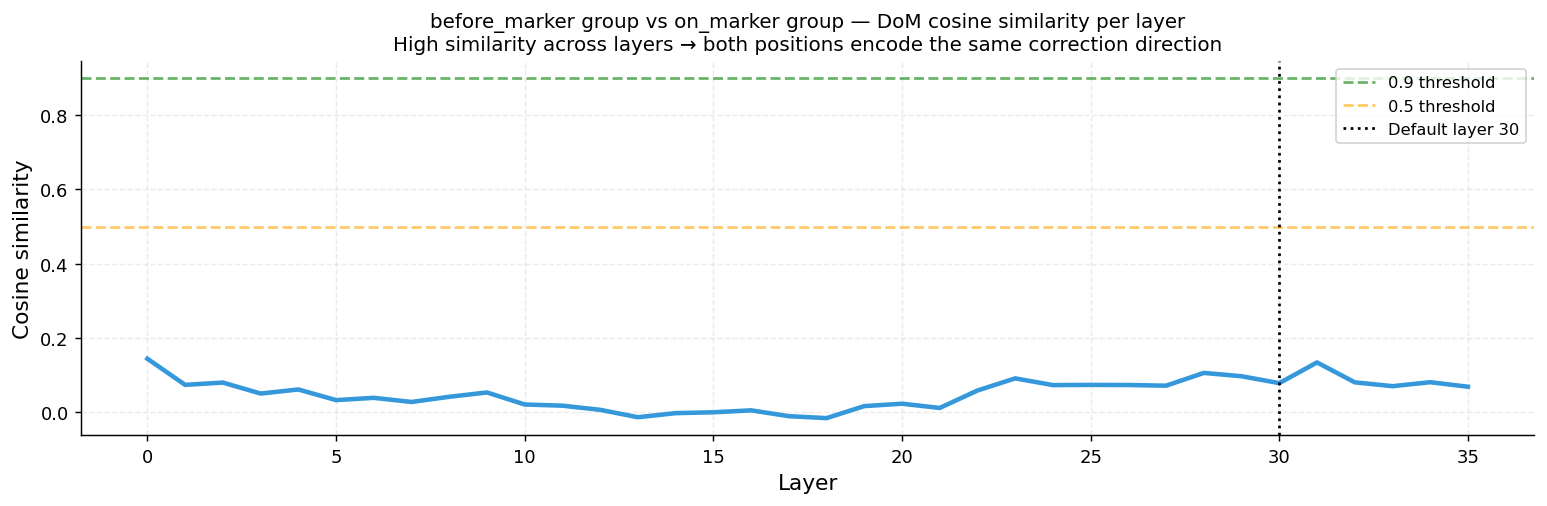

In [ ]:
# ── 11. IS "BEFORE" vs "ON" STYLISTIC vs GENUINE? ───────────────
#
# Hypothesis: cases where the marker appears predictably BEFORE itself
# (logit lens peaks before the token) might be structurally different
# from cases where it only becomes salient ON the token.
# We test whether the two groups produce different DoM directions.

before_group = [e for e in all_extractions if e['position_type'] == 'before_marker']
on_group     = [e for e in all_extractions if e['position_type'] == 'on_marker']

print(f"before_marker group: n={len(before_group)}")
print(f"on_marker group:     n={len(on_group)}")

def group_dom(group, layer):
    """DoM vector for a subset of cases at a given layer."""
    if not group:
        return None
    acts_pos = np.stack([e['acts_before'] if e['position_type'] == 'before_marker'
                         else e['acts_on'] for e in group], axis=0)
    acts_cf  = np.stack([e['acts_cf'] for e in group], axis=0)
    return acts_pos.mean(0)[layer] - acts_cf.mean(0)[layer]


if before_group and on_group:
    layer = DEFAULT_STEERING_LAYER
    vec_bef_group = group_dom(before_group, layer)
    vec_on_group  = group_dom(on_group,     layer)
    sim = float(cosine_similarity(
        vec_bef_group.reshape(1,-1),
        vec_on_group.reshape(1,-1)
    )[0,0])
    print(f"\nCosine similarity between before_group and on_group DoM"
          f" at layer {layer}: {sim:.4f}")
    print("  > 0.9  → they encode the same direction (both are genuine, not stylistic)")
    print("  < 0.5  → they might reflect different phenomena (worth investigating)")

    # visualise
    sims_by_layer = []
    for l in range(n_layers):
        v_b = group_dom(before_group, l)
        v_o = group_dom(on_group, l)
        if v_b is not None and v_o is not None:
            s = float(cosine_similarity(v_b.reshape(1,-1), v_o.reshape(1,-1))[0,0])
        else:
            s = 0.0
        sims_by_layer.append(s)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sims_by_layer, color=PALETTE['before'], linewidth=2.5)
    ax.axhline(0.9, color='green', linestyle='--', alpha=0.6, label='0.9 threshold')
    ax.axhline(0.5, color='orange', linestyle='--', alpha=0.6, label='0.5 threshold')
    ax.axvline(DEFAULT_STEERING_LAYER, color='black', linestyle=':',
               label=f'Default layer {DEFAULT_STEERING_LAYER}')
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel('Cosine similarity', fontsize=12)
    ax.set_title(
        'before_marker group vs on_marker group — DoM cosine similarity per layer\n'
        'High similarity across layers → both positions encode the same correction direction',
        fontsize=11
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/position_group_similarity.png', dpi=130)
    plt.show()
    plt.close()

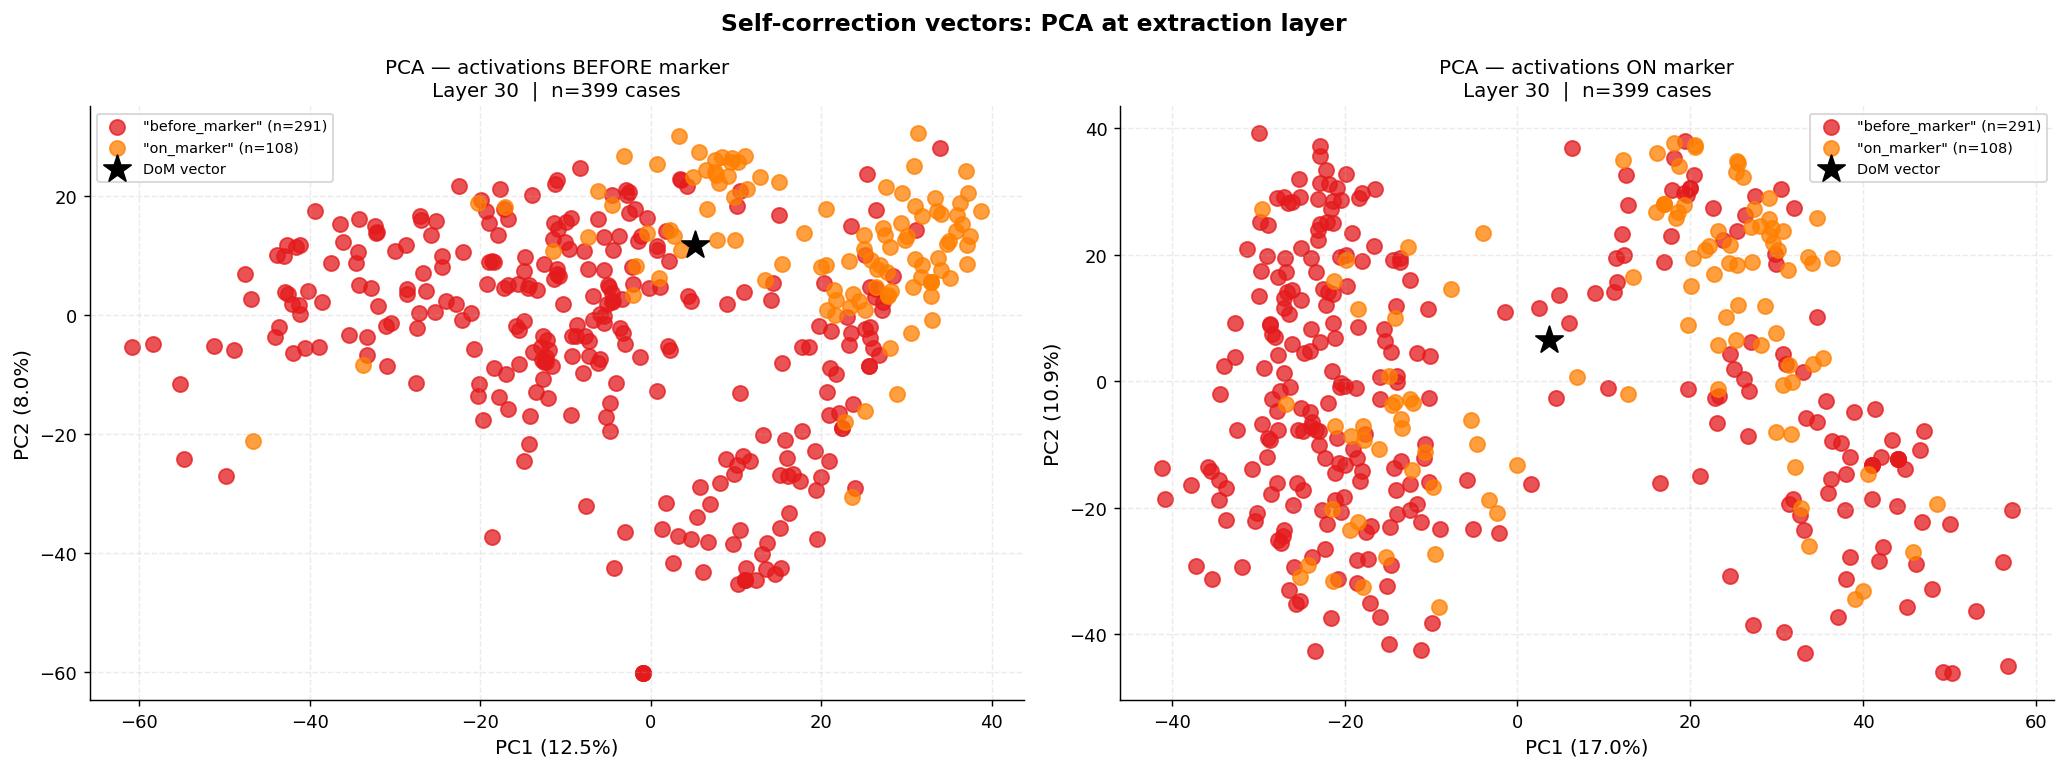

In [ ]:
# ── 12. PCA OF EXTRACTION VECTORS ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

layer = DEFAULT_STEERING_LAYER

for ax, pos_type, color, label in zip(
    axes,
    ['acts_before', 'acts_on'],
    [PALETTE['before'], PALETTE['on']],
    ['BEFORE marker', 'ON marker']
):
    vecs = np.stack([e[pos_type][layer] for e in all_extractions], axis=0)
    pca  = PCA(n_components=2, random_state=RANDOM_SEED)
    coords = pca.fit_transform(StandardScaler().fit_transform(vecs))
    var1, var2 = pca.explained_variance_ratio_[:2] * 100

    # colour PCA by position_type
    position_labels = [e['position_type'] for e in all_extractions]

    markers_list = [e['marker'] for e in all_extractions]
    unique_m     = list(set(position_labels))
    cmap         = plt.cm.Set1

    for j, m in enumerate(unique_m):
        idxs = [k for k, mk in enumerate(position_labels) if mk == m]
        ax.scatter(
            coords[idxs, 0], coords[idxs, 1],
            c=[cmap(j / max(len(unique_m), 1))],
            alpha=0.75, s=70, label=f'"{m}" (n={len(idxs)})'
        )

    mean_vec = dom_before[layer] if pos_type == 'acts_before' else dom_on[layer]
    mean_sc  = StandardScaler().fit(vecs).transform(mean_vec.reshape(1,-1))
    mean_c   = pca.transform(mean_sc)
    ax.scatter(mean_c[0,0], mean_c[0,1], c='black', s=250,
               marker='*', zorder=5, label='DoM vector')

    ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=11)
    ax.set_title(
        f'PCA — activations {label}\n'
        f'Layer {layer}  |  n={len(vecs)} cases',
        fontsize=11
    )
    ax.legend(fontsize=8)

plt.suptitle('Self-correction vectors: PCA at extraction layer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_extraction_vectors.png', dpi=130)
plt.show()
plt.close()

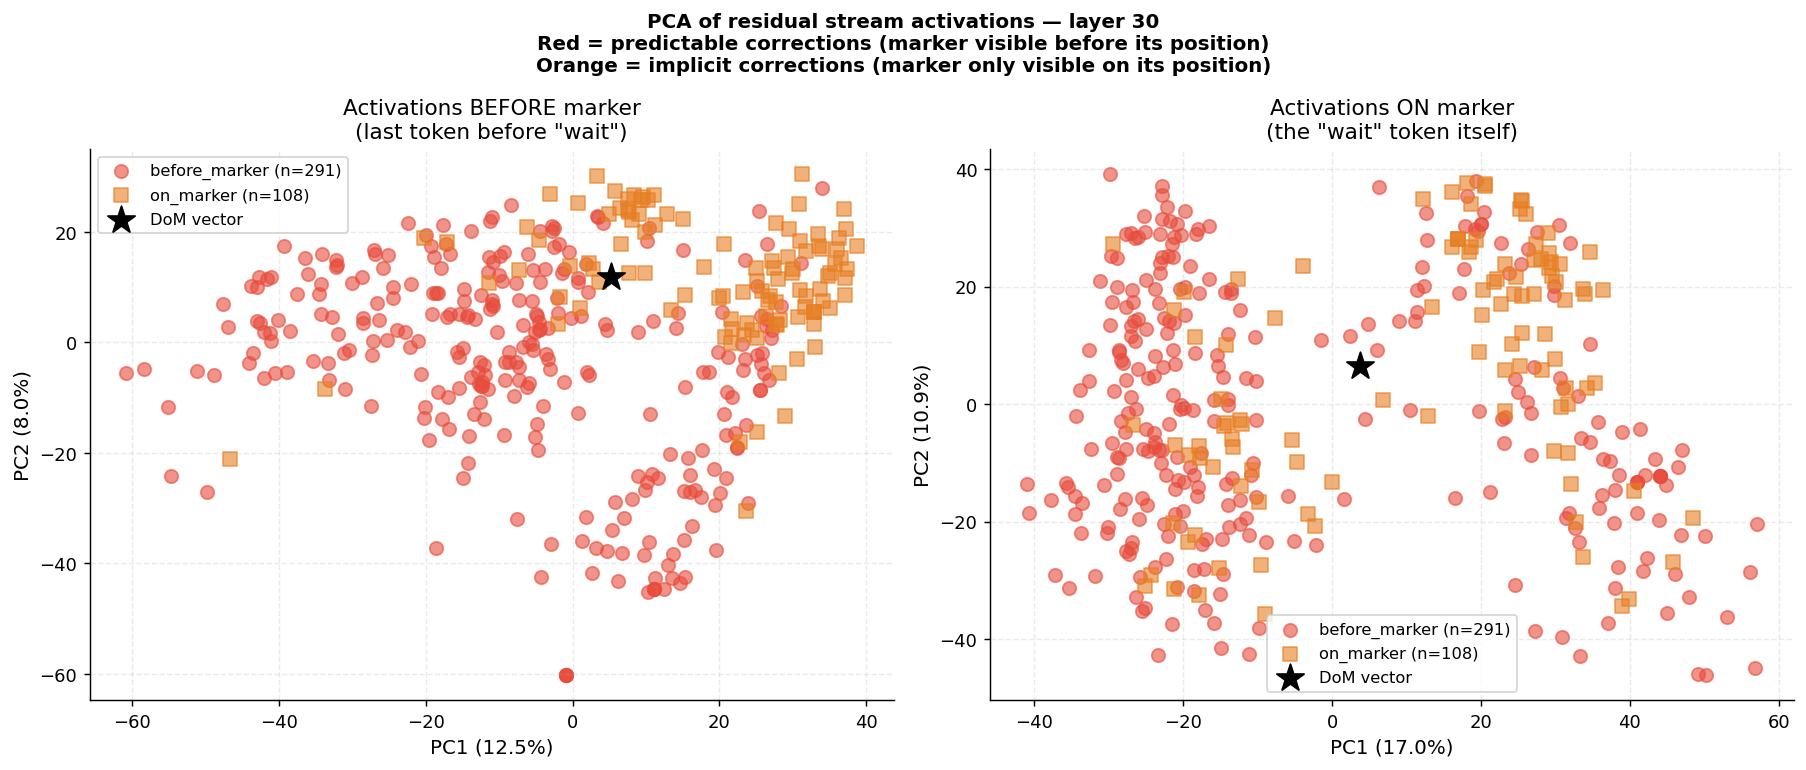

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

configs = [
    ('acts_before', 'dom_before', 'Activations BEFORE marker\n(last token before "wait")'),
    ('acts_on',     'dom_on',     'Activations ON marker\n(the "wait" token itself)'),
]

dom_vecs = {
    'acts_before': dom_before[DEFAULT_STEERING_LAYER],
    'acts_on':     dom_on[DEFAULT_STEERING_LAYER],
}

for ax, (acts_key, dom_key, title) in zip(axes, configs):
    # collect vectors for the two groups
    before_vecs = np.stack(
        [e[acts_key][DEFAULT_STEERING_LAYER] for e in all_extractions
         if e['position_type'] == 'before_marker'], axis=0
    )
    on_vecs = np.stack(
        [e[acts_key][DEFAULT_STEERING_LAYER] for e in all_extractions
         if e['position_type'] == 'on_marker'], axis=0
    )

    all_vecs = np.vstack([before_vecs, on_vecs])
    labels   = (['before_marker'] * len(before_vecs)
                + ['on_marker']   * len(on_vecs))

    scaler = StandardScaler()
    scaled = scaler.fit_transform(all_vecs)
    pca    = PCA(n_components=2, random_state=RANDOM_SEED)
    coords = pca.fit_transform(scaled)
    v1, v2 = pca.explained_variance_ratio_[:2] * 100

    # scatter: before_marker vs on_marker
    for lbl, color, marker_shape in [
        ('before_marker', '#e74c3c', 'o'),
        ('on_marker',     '#e67e22', 's'),
    ]:
        idxs = [i for i, l in enumerate(labels) if l == lbl]
        ax.scatter(coords[idxs, 0], coords[idxs, 1],
                   c=color, marker=marker_shape,
                   alpha=0.6, s=55, label=f'{lbl} (n={len(idxs)})')

    # DoM vector projected into the same PCA space
    dom_vec = dom_before[DEFAULT_STEERING_LAYER] if acts_key == 'acts_before' else dom_on[DEFAULT_STEERING_LAYER]
    dom_scaled = scaler.transform(dom_vec.reshape(1, -1))
    dom_coords = pca.transform(dom_scaled)
    ax.scatter(dom_coords[0, 0], dom_coords[0, 1],
               c='black', s=250, marker='*', zorder=5, label='DoM vector')

    ax.set_xlabel(f'PC1 ({v1:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({v2:.1f}%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle(
    f'PCA of residual stream activations — layer {DEFAULT_STEERING_LAYER}\n'
    'Red = predictable corrections (marker visible before its position)\n'
    'Orange = implicit corrections (marker only visible on its position)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_before_vs_on_clean.png', dpi=130,
            bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
# ── QUALITATIVE ANALYSIS: what contexts lead to before_marker vs on_marker? ──
# We project all cases onto PC1 (the axis that best separates the two groups
# in the BEFORE-marker PCA) and look at the extreme cases on each end.
# This tells us: what kind of reasoning context precedes predictable vs
# implicit corrections?

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# rebuild the PCA from the BEFORE-marker activations (same as in the plot)
before_vecs_all = np.stack(
    [e['acts_before'][DEFAULT_STEERING_LAYER] for e in all_extractions], axis=0
)
labels_all = [e['position_type'] for e in all_extractions]

scaler = StandardScaler()
scaled = scaler.fit_transform(before_vecs_all)
pca    = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(scaled)

# PC1 scores for every case
pc1_scores = coords[:, 0]

# attach PC1 score to each extraction result
for i, ext in enumerate(all_extractions):
    ext['pc1_before'] = float(pc1_scores[i])

# sort by PC1: left end = before_marker cluster, right end = on_marker cluster
sorted_by_pc1 = sorted(all_extractions, key=lambda x: x['pc1_before'])

print("=" * 70)
print("LOW PC1 — cases on the LEFT of the plot (mostly before_marker / red)")
print("=" * 70)
for ext in sorted_by_pc1[:10]:
    # find the original case to get context
    case_match = [c for c in cases_for_extraction
                  if c['question_id'] == ext['question_id']]
    if not case_match:
        continue
    case = case_match[0]
    print(f"\nQ{ext['question_id']} | position_type={ext['position_type']}"
          f" | PC1={ext['pc1_before']:.1f}")
    print(f"  Question:  {case['question_text'][:120]}")
    print(f"  Context before 'wait':")
    print(f"    {case.get('context_before', '')[:300]}")
    print(f"  Context after 'wait':")
    print(f"    {case.get('context_after', '')[:200]}")
    print(f"  Reasoning: {case.get('reasoning', '')}")

print("\n" + "=" * 70)
print("HIGH PC1 — cases on the RIGHT of the plot (mostly on_marker / orange)")
print("=" * 70)
for ext in sorted_by_pc1[-10:]:
    case_match = [c for c in cases_for_extraction
                  if c['question_id'] == ext['question_id']]
    if not case_match:
        continue
    case = case_match[0]
    print(f"\nQ{ext['question_id']} | position_type={ext['position_type']}"
          f" | PC1={ext['pc1_before']:.1f}")
    print(f"  Question:  {case['question_text'][:120]}")
    print(f"  Context before 'wait':")
    print(f"    {case.get('context_before', '')[:300]}")
    print(f"  Context after 'wait':")
    print(f"    {case.get('context_after', '')[:200]}")
    print(f"  Reasoning: {case.get('reasoning', '')}")

# also: simple frequency count — which position_type dominates each end?
low_pc1  = sorted_by_pc1[:50]
high_pc1 = sorted_by_pc1[-50:]

low_before  = sum(1 for e in low_pc1  if e['position_type'] == 'before_marker')
high_before = sum(1 for e in high_pc1 if e['position_type'] == 'before_marker')

print(f"\n{'='*70}")
print(f"Position type distribution at PC1 extremes (top/bottom 50):")
print(f"  Low  PC1: before_marker={low_before}/50, "
      f"on_marker={50-low_before}/50")
print(f"  High PC1: before_marker={high_before}/50, "
      f"on_marker={50-high_before}/50")

LOW PC1 — cases on the LEFT of the plot (mostly before_marker / red)

Q24 | position_type=before_marker | PC1=-60.8
  Question:  Let $k$ be a real number such that the system
\begin{align*} |25+20i-z|&=5\\ |z-4-k|&=|z-3i-k| \\ \end{align*}
has exact
  Context before 'wait':
    = | ( x - 4 ) + ( y - k ) i | . right side : | ( x + yi ) - ( 3i + k ) | = | ( x - 0 ) + ( y - 3 ) i - k | ?
  Context after 'wait':
    , hold on . wait , z - 3i - k is ( x + yi ) - 3i - k = ( x - k ) + ( y - 3 ) i . wait , no . wait , k is a real number . so , 3i
  Reasoning: User corrects modulus expression handling

Q24 | position_type=before_marker | PC1=-58.4
  Question:  Let $k$ be a real number such that the system
\begin{align*} |25+20i-z|&=5\\ |z-4-k|&=|z-3i-k| \\ \end{align*}
has exact
  Context before 'wait':
    = | ( x - 4 ) + ( y - k ) i | . right side : | ( x + yi ) - ( 3i + k ) | = | ( x - 0 ) + ( y - 3 ) i - k | ?
  Context after 'wait':
    , hold on . wait , z - 3i - k is ( x + yi ) - 3i - k 

In [ ]:
# load category from classified file
with open(CLASSIFIED_FILE, 'r', encoding='utf-8') as f:
    classified_data = json.load(f)

category_lookup = {
    q['id']: q.get('category', 'unknown')
    for q in classified_data.get('questions', [])
}

for ext in all_extractions:
    ext['category'] = category_lookup.get(ext['question_id'], 'unknown')

cat_counts = Counter(ext['category'] for ext in all_extractions)
print("Categories in extraction data:")
for cat, n in cat_counts.most_common():
    print(f"  {cat}: {n}")

Categories in extraction data:
  math_trick: 231
  conflicting: 89
  ambiguous: 79


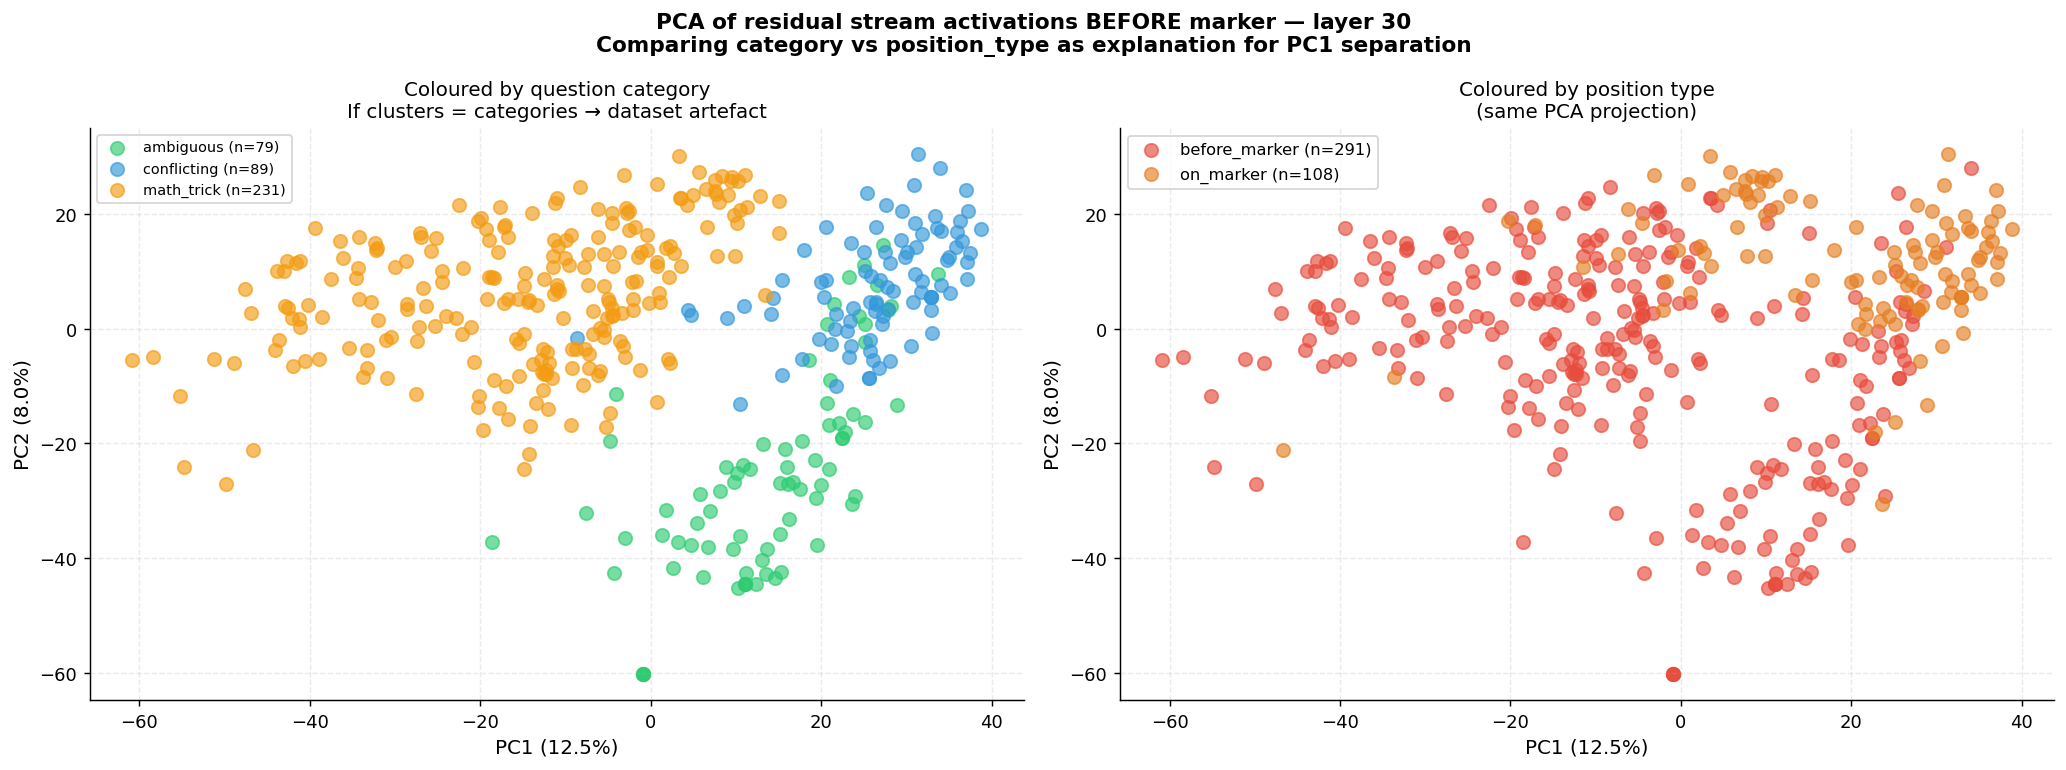


Mean PC1 score by category:
  ambiguous      : PC1 = +13.66 ± 10.03  (n=79)
  conflicting    : PC1 = +26.48 ± 8.30  (n=89)
  math_trick     : PC1 = -14.88 ± 16.43  (n=231)

Mean PC1 score by position_type:
  before_marker  : PC1 = -7.10 ± 20.57  (n=291)
  on_marker      : PC1 = +19.12 ± 15.96  (n=108)


In [ ]:
# rebuild PCA (same as before, BEFORE-marker activations)
before_vecs_all = np.stack(
    [e['acts_before'][DEFAULT_STEERING_LAYER] for e in all_extractions],
    axis=0
)

scaler = StandardScaler()
scaled = scaler.fit_transform(before_vecs_all)
pca    = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(scaled)
v1, v2 = pca.explained_variance_ratio_[:2] * 100

categories    = [ext['category'] for ext in all_extractions]
position_types = [ext['position_type'] for ext in all_extractions]
unique_cats   = sorted(set(categories))

# colour palette for categories
cat_colors = {
    'conflicting'  : '#3498db',
    'mathematical' : '#e74c3c',
    'ambiguous'    : '#2ecc71',
    'factual'      : '#e67e22',
    'unknown'      : '#95a5a6',
}
# fallback colours if categories differ from expected
fallback = ['#9b59b6', '#1abc9c', '#f39c12', '#d35400', '#c0392b']
for i, cat in enumerate(unique_cats):
    if cat not in cat_colors:
        cat_colors[cat] = fallback[i % len(fallback)]

# ── Figure: two panels side by side ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# panel 1: coloured by CATEGORY
ax = axes[0]
for cat in unique_cats:
    idxs = [i for i, c in enumerate(categories) if c == cat]
    ax.scatter(
        coords[idxs, 0], coords[idxs, 1],
        c=cat_colors[cat], alpha=0.65, s=55,
        label=f'{cat} (n={len(idxs)})'
    )
ax.set_xlabel(f'PC1 ({v1:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({v2:.1f}%)', fontsize=11)
ax.set_title('Coloured by question category\n'
             'If clusters = categories → dataset artefact',
             fontsize=11)
ax.legend(fontsize=8, loc='upper left')

# panel 2: coloured by POSITION TYPE (same PCA, different colour)
ax2 = axes[1]
pos_colors = {'before_marker': '#e74c3c', 'on_marker': '#e67e22'}
for pos_type, color in pos_colors.items():
    idxs = [i for i, p in enumerate(position_types) if p == pos_type]
    ax2.scatter(
        coords[idxs, 0], coords[idxs, 1],
        c=color, alpha=0.65, s=55,
        label=f'{pos_type} (n={len(idxs)})'
    )
ax2.set_xlabel(f'PC1 ({v1:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({v2:.1f}%)', fontsize=11)
ax2.set_title('Coloured by position type\n'
              '(same PCA projection)',
              fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle(
    f'PCA of residual stream activations BEFORE marker — layer {DEFAULT_STEERING_LAYER}\n'
    'Comparing category vs position_type as explanation for PC1 separation',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_category_vs_position_type.png',
            dpi=130, bbox_inches='tight')
plt.show()
plt.close()

# ── quantitative check: does PC1 separate categories? ────────────
print("\nMean PC1 score by category:")
for cat in unique_cats:
    idxs  = [i for i, c in enumerate(categories) if c == cat]
    mean  = np.mean(coords[idxs, 0])
    std   = np.std(coords[idxs, 0])
    print(f"  {cat:15s}: PC1 = {mean:+.2f} ± {std:.2f}  (n={len(idxs)})")

print("\nMean PC1 score by position_type:")
for pos in ['before_marker', 'on_marker']:
    idxs  = [i for i, p in enumerate(position_types) if p == pos]
    mean  = np.mean(coords[idxs, 0])
    std   = np.std(coords[idxs, 0])
    print(f"  {pos:15s}: PC1 = {mean:+.2f} ± {std:.2f}  (n={len(idxs)})")

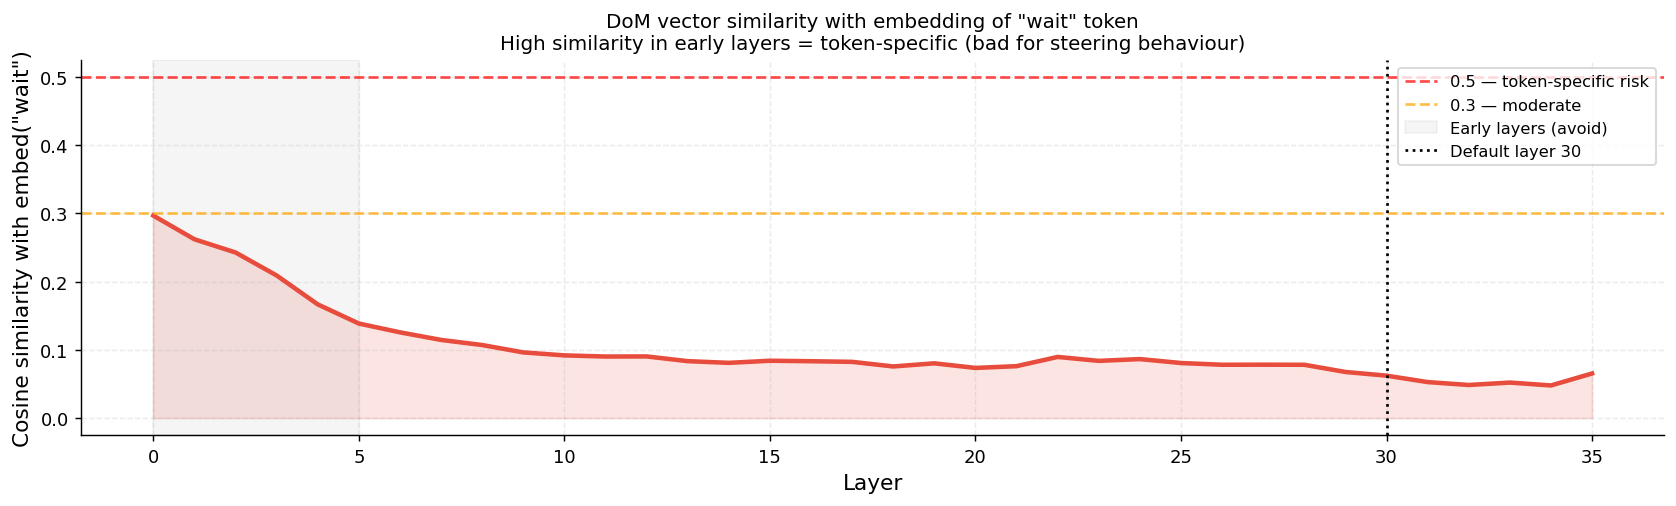


Embedding correlation by layer:
  layer   0: 0.2968
  layer   1: 0.2620
  layer   2: 0.2427
  layer   3: 0.2090
  layer   4: 0.1666
  layer   5: 0.1386
  layer   6: 0.1257
  layer   7: 0.1145
  layer   8: 0.1070
  layer   9: 0.0962
  layer  10: 0.0919
  layer  11: 0.0902
  layer  12: 0.0904
  layer  13: 0.0834
  layer  14: 0.0809
  layer  15: 0.0840
  layer  16: 0.0833
  layer  17: 0.0824
  layer  18: 0.0757
  layer  19: 0.0802
  layer  20: 0.0735
  layer  21: 0.0761
  layer  22: 0.0896
  layer  23: 0.0838
  layer  24: 0.0865
  layer  25: 0.0807
  layer  26: 0.0781
  layer  27: 0.0782
  layer  28: 0.0781
  layer  29: 0.0676
  layer  30: 0.0622
  layer  31: 0.0528
  layer  32: 0.0485
  layer  33: 0.0520
  layer  34: 0.0478
  layer  35: 0.0654

Layers with low embedding correlation (sim<0.3, layer>=5): [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


In [ ]:
# ── 13. EMBEDDING CORRELATION ────────────────────────────────────
# Early transformer layers tend to keep the residual stream close to
# the raw token embedding. If our steering vector is extracted from such
# a layer, it will mostly encode "this is the token <wait>" rather than
# "this is the self-correction behaviour" — steering with it would just
# force the model to produce the word "wait", not actually reconsider.
#
# We measure cosine similarity between the DoM vector at each layer
# and the embedding of the "wait" token to spot this problem.

marker_token = 'wait'
marker_ids   = tokenizer.encode(' ' + marker_token, add_special_tokens=False)
if not marker_ids:
    marker_ids = tokenizer.encode(marker_token, add_special_tokens=False)
marker_id    = marker_ids[0]

embed_matrix    = model.embed.W_E.detach().cpu().float().numpy()
marker_embedding = embed_matrix[marker_id]  # [d_model]

sims_embed = []
for layer in range(n_layers):
    v   = dom_combined[layer]
    sim = float(cosine_similarity(v.reshape(1,-1), marker_embedding.reshape(1,-1))[0,0])
    sims_embed.append(sim)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sims_embed, color=PALETTE['correction'], linewidth=2.5)
ax.fill_between(range(n_layers), sims_embed, alpha=0.15, color=PALETTE['correction'])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='0.5 — token-specific risk')
ax.axhline(0.3, color='orange', linestyle='--', alpha=0.7, label='0.3 — moderate')
ax.axvspan(0, 5, alpha=0.08, color='gray', label='Early layers (avoid)')
ax.axvline(DEFAULT_STEERING_LAYER, color='black', linestyle=':',
           label=f'Default layer {DEFAULT_STEERING_LAYER}')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel(f'Cosine similarity with embed("{marker_token}")', fontsize=12)
ax.set_title(
    f'DoM vector similarity with embedding of "{marker_token}" token\n'
    'High similarity in early layers = token-specific (bad for steering behaviour)',
    fontsize=11
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/embedding_correlation.png', dpi=130)
plt.show()
plt.close()

print("\nEmbedding correlation by layer:")
for l, s in enumerate(sims_embed):
    flag = "  ← HIGH (token-specific, avoid)" if s > 0.5 else ""
    print(f"  layer {l:>3}: {s:.4f}{flag}")

good_layers = [l for l, s in enumerate(sims_embed) if s < 0.3 and l >= 5]
print(f"\nLayers with low embedding correlation (sim<0.3, layer>=5): {good_layers}")

  Attribution patching: 10/50
  Attribution patching: 20/50
  Attribution patching: 30/50
  Attribution patching: 40/50
  Attribution patching: 50/50


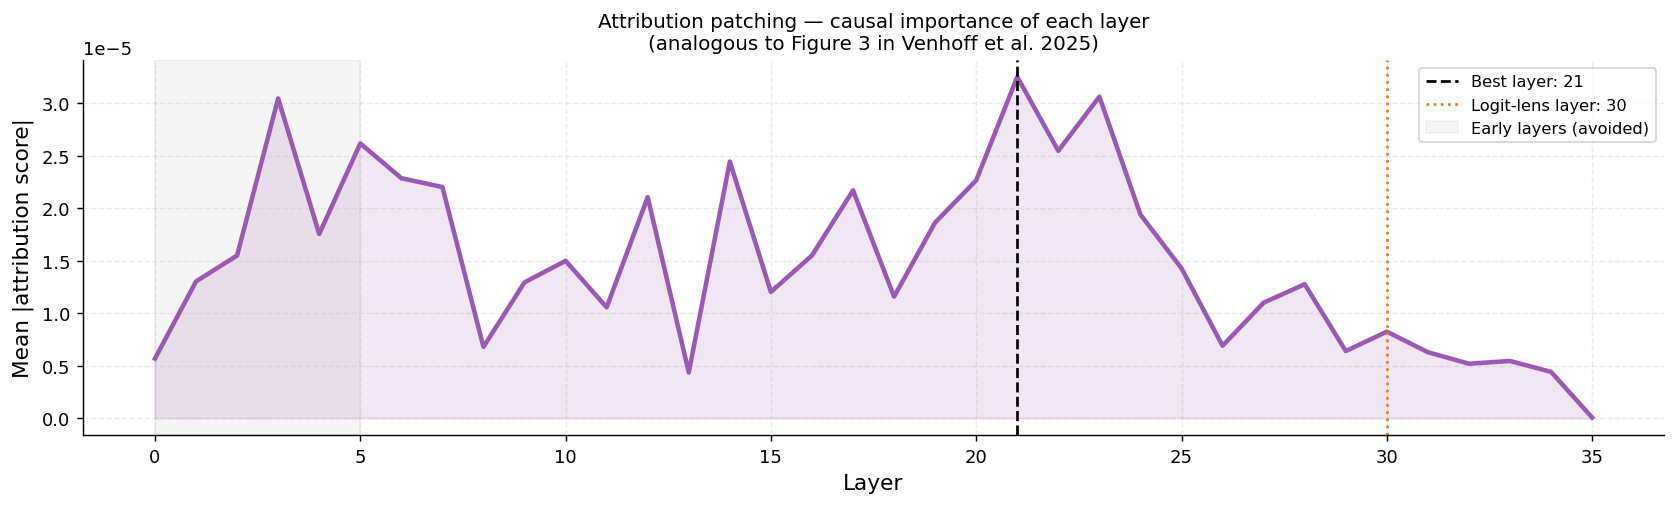


Best layer by attribution patching: 21
Default layer by logit lens:        30


In [ ]:
# ── 14. ATTRIBUTION PATCHING (fixed) ────────────────────────────
# Linear approximation of activation patching (Nanda 2023):
#   score_l = |dot(u_l, grad_KL/grad_a_l)|
# We keep the model in float16 but compute gradients in float32
# by casting the captured activation before the rest of the forward pass.
# The key fix: we must NOT convert back to half() inside the hook,
# because that breaks the computational graph for autograd.

N_ATTR_CASES = min(50, len(all_extractions))

sv_norm = dom_combined[DEFAULT_STEERING_LAYER]
sv_norm = sv_norm / (np.linalg.norm(sv_norm) + 1e-8)

all_scores = np.zeros((N_ATTR_CASES, n_layers))

for case_idx, ext in enumerate(all_extractions[:N_ATTR_CASES]):
    # rebuild token ids for this case
    case_match = [c for c in cases_for_extraction
                  if c['question_id'] == ext['question_id']]
    if not case_match:
        continue
    case = case_match[0]

    prefix = build_prefix(tokenizer, case['question_text'])
    ids_before = tokenizer.encode(
        prefix + case.get('context_before', '')
    )[-MAX_TOKENS:]

    if len(ids_before) < 10:
        continue

    input_t = torch.tensor([ids_before], dtype=torch.long).to('cuda:0')

    with torch.no_grad():
        logits_clean = model(input_t)[0, -1, :].float()
        probs_clean  = torch.softmax(logits_clean, dim=-1).detach()

    for layer_idx in range(n_layers):
        hook_name  = f'blocks.{layer_idx}.hook_resid_post'
        saved_act  = {}

        def make_hook(li):
            def hfn(value, hook):
                # cast to float32 and keep in graph — do NOT convert back to half
                act_f32 = value.float()
                act_f32.requires_grad_(True)
                saved_act[f'a{li}'] = act_f32
                # return float32; TransformerLens handles mixed precision
                return act_f32
            return hfn

        try:
            with torch.enable_grad():
                out = model.run_with_hooks(
                    input_t,
                    fwd_hooks=[(hook_name, make_hook(layer_idx))]
                )
                probs_h = torch.softmax(out[0, -1, :].float(), dim=-1)
                # KL(clean || patched)
                kl = (probs_clean *
                      (torch.log(probs_clean + 1e-10)
                       - torch.log(probs_h + 1e-10))).sum()

                key = f'a{layer_idx}'
                if key in saved_act:
                    grad = torch.autograd.grad(
                        kl, saved_act[key], allow_unused=True
                    )[0]
                    if grad is not None:
                        g = grad[0, -1, :].detach().cpu().float().numpy()
                        all_scores[case_idx, layer_idx] = abs(
                            np.dot(sv_norm, g)
                        )
        except Exception as e:
            pass

        torch.cuda.empty_cache()

    if (case_idx + 1) % 10 == 0:
        print(f"  Attribution patching: {case_idx+1}/{N_ATTR_CASES}")

mean_attr = all_scores.mean(axis=0)
np.save(f'{OUTPUT_DIR}/attribution_scores.npy', mean_attr)

# best layer: highest attribution among layers with low embedding correlation
filtered_attr = mean_attr.copy()
for l in range(len(filtered_attr)):
    if sims_embed[l] >= 0.3:  # exclude token-specific layers
        filtered_attr[l] = 0.0
BEST_LAYER_ATTR = int(np.argmax(filtered_attr[5:]) + 5)  # skip first 5

# plot
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mean_attr, color='#9b59b6', linewidth=2.5)
ax.fill_between(range(n_layers), mean_attr, alpha=0.15, color='#9b59b6')
ax.axvline(BEST_LAYER_ATTR, color='black', linestyle='--',
           label=f'Best layer: {BEST_LAYER_ATTR}')
ax.axvline(DEFAULT_STEERING_LAYER, color='#e67e22', linestyle=':',
           label=f'Logit-lens layer: {DEFAULT_STEERING_LAYER}')
ax.axvspan(0, 5, alpha=0.08, color='gray', label='Early layers (avoided)')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Mean |attribution score|', fontsize=12)
ax.set_title(
    'Attribution patching — causal importance of each layer\n'
    '(analogous to Figure 3 in Venhoff et al. 2025)',
    fontsize=11
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/attribution_patching.png', dpi=130)
plt.show()
plt.close()

STEERING_LAYER = BEST_LAYER_ATTR
print(f"\nBest layer by attribution patching: {BEST_LAYER_ATTR}")
print(f"Default layer by logit lens:        {DEFAULT_STEERING_LAYER}")

In [ ]:
# ── 15. STEERING FUNCTION ────────────────────────────────────────

def generate_with_steering(model, tokenizer, prompt_tokens,
                            steering_vector, coeff,
                            steering_layer, max_new_tokens=300,
                            only_last_position=True):
    """
    Autoregressive generation with a steering vector added to residual
    stream at every step.

    only_last_position=True  → add vector only to the last (newly generated)
                               token position — more surgical
    only_last_position=False → add to all positions — stronger effect

    coeff > 0 → amplify self-correction
    coeff < 0 → suppress self-correction (negative steering)
    """
    # find which device the target layer is on
    layer_device = next(
        model.blocks[steering_layer].parameters()
    ).device

    sv_tensor = torch.tensor(
        steering_vector, dtype=torch.float16
    ).to(layer_device)  # send to the same device as the layer

    hook_name = f'blocks.{steering_layer}.hook_resid_post'

    def steering_hook(value, hook):
        return value + coeff * sv_tensor

    input_tensor  = torch.tensor(
        [prompt_tokens], dtype=torch.long
    ).to('cuda:0')  # input always starts on cuda:0
    generated_ids = []

    with torch.no_grad():
        current_input = input_tensor
        for _ in range(max_new_tokens):
            logits     = model.run_with_hooks(
                current_input,
                fwd_hooks=[(hook_name, steering_hook)]
            )
            next_token = torch.argmax(logits[0, -1, :]).item()
            generated_ids.append(next_token)
            next_tensor   = torch.tensor(
                [[next_token]], dtype=torch.long
            ).to('cuda:0')
            current_input = torch.cat(
                [current_input, next_tensor], dim=1
            )
            decoded = tokenizer.decode(generated_ids)
            if (next_token == tokenizer.eos_token_id
                    or '</think>' in decoded):
                break

    return tokenizer.decode(generated_ids)

def count_correction_markers(text, markers=None):
    """Count self-correction markers in generated text."""
    if markers is None:
        markers = ['wait', 'actually', 'let me reconsider', 'correction',
                   'sorry', 'i meant', 'my mistake', 'on second thought',
                   'hang on', 'hold on', "that's not right", 'i made an error']
    text_lower = text.lower()
    counts = {m: text_lower.count(m) for m in markers if text_lower.count(m) > 0}
    return counts, sum(counts.values())

In [ ]:
# ── 16. BENCHMARK PROMPTS ───────────────────────────────────────
# Instead of a handwritten list, we use established benchmarks.
# HARD prompts: problems that require genuine re-checking (math, logic traps)
# EASY prompts: trivial factual lookups where overthinking hurts efficiency
#
# Hard prompts come from GSM8K (grade-school math) and ARC Challenge.
# Easy prompts come from TriviaQA (easy split) and common factual queries.

try:
    from datasets import load_dataset
    gsm8k   = load_dataset("gsm8k", "main", split="test").shuffle(seed=RANDOM_SEED).select(range(25))
    arc_ch  = load_dataset("ai2_arc", "ARC-Challenge", split="test").shuffle(seed=RANDOM_SEED).select(range(15))
    triviaqa = load_dataset("trivia_qa", "rc.nocontext", split="validation").shuffle(seed=RANDOM_SEED).select(range(20))

    HARD_PROMPTS = (
        [q["question"] + "\nThink carefully and show your work." for q in gsm8k]
        + [q["question"] + "\nChoose the correct answer and explain your reasoning."
           for q in arc_ch]
    )
    EASY_PROMPTS = (
        [q["question"] for q in triviaqa]
        + [
            "What is 2 + 2?",
            "What color is the sky on a clear day?",
            "How many days are in a week?",
            "What is the capital of France?",
            "Name the days of the week.",
            "What language do people speak in France?",
            "How many months are in a year?",
            "What is the chemical symbol for water?",
        ]
    )

    # ground-truth answers for accuracy scoring
    GSM8K_ANSWERS = [
        re.search(r' #### (-?\d[\d,]*)', q["answer"]).group(1).replace(',', '')
        if re.search(r' #### (-?\d[\d,]*)', q["answer"]) else ''
        for q in gsm8k
    ]

    print(f"Loaded {len(HARD_PROMPTS)} hard prompts and {len(EASY_PROMPTS)} easy prompts.")

except Exception as e:
    print(f"Dataset loading failed ({e}). Falling back to built-in prompt lists.")
    HARD_PROMPTS = [
        "A bat and a ball cost $1.10 in total. The bat costs $1 more than the ball. How much does the ball cost? Show your work.",
        "What is the capital of Australia? Think step by step.",
        "If you have 3 apples and take away 2, how many apples do you have? Think carefully.",
        "A lily pad doubles in size every day. After 48 days it covers the whole lake. How long does it take to cover half the lake? Show reasoning.",
        "There are 23 sheep. All but 9 run away. How many sheep are left?",
        "Two trains leave different cities 500 km apart heading toward each other at 60 and 40 km/h. When do they meet?",
        "A snail climbs 3m up a 10m wall each day and slides back 2m each night. When does it reach the top?",
        "Is a tomato a fruit or a vegetable? Consider biology and culinary tradition.",
    ]
    EASY_PROMPTS = [
        "What is 2 + 2?",
        "What color is the sky on a clear day?",
        "Name the days of the week.",
        "What is the capital of France?",
        "What language do people speak in France?",
        "How many months are in a year?",
        "What is the chemical symbol for water?",
        "How many sides does a triangle have?",
    ]
    GSM8K_ANSWERS = []  # no ground-truth available

ALL_PROMPTS  = HARD_PROMPTS + EASY_PROMPTS
PROMPT_TYPES = (['hard'] * len(HARD_PROMPTS)) + (['easy'] * len(EASY_PROMPTS))
print(f"Total prompts: {len(ALL_PROMPTS)}")

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Loaded 40 hard prompts and 28 easy prompts.
Total prompts: 68


In [ ]:
# ── 17. STEERING EXPERIMENT ─────────────────────────────────────
# Positive steering (coeff > 0): inject the self-correction vector → more backtracking
# Negative steering (coeff < 0): subtract it → suppress unnecessary rechecking
#
# We test across multiple layers and coefficients to find the sweet spot.

activation_norm = float(np.linalg.norm(dom_combined[STEERING_LAYER]))
sv_scaled       = dom_combined[STEERING_LAYER] / activation_norm

np.random.seed(RANDOM_SEED)
sv_random       = np.random.randn(d_model).astype(np.float32)
sv_random       = sv_random / np.linalg.norm(sv_random)

# coefficients: positive for hard, negative for easy
# scaled so coeff * sv ≈ fraction of the typical activation norm
COEFFS_POS = [0, 50, 100, 150]    # for hard tasks
COEFFS_NEG = [0, -50, -100, -150] # for easy tasks
ALL_COEFFS  = list(set(COEFFS_POS + COEFFS_NEG))

results = {}  # keyed by (prompt_idx, coeff)
all_texts = []

print("=" * 65)
print(f"STEERING EXPERIMENT  |  layer={STEERING_LAYER}  |  n={len(ALL_PROMPTS)} prompts")
print("=" * 65)

for p_idx, (prompt_text, ptype) in enumerate(zip(ALL_PROMPTS, PROMPT_TYPES)):
    print(f"\n[{p_idx+1}/{len(ALL_PROMPTS)}] [{ptype.upper()}] {prompt_text[:70]}...")
    prompt_tokens = build_test_prompt_tokens(tokenizer, prompt_text)
    prompt_record = {'prompt': prompt_text, 'type': ptype, 'conditions': []}

    # only test relevant coefficients per type
    test_coeffs = COEFFS_POS if ptype == 'hard' else COEFFS_NEG

    for coeff in test_coeffs:
        torch.cuda.empty_cache()
        gc.collect()

        gen_corr = generate_with_steering(
            model, tokenizer, prompt_tokens,
            sv_scaled, coeff, STEERING_LAYER, only_last_position=True
        )
        gen_rand = generate_with_steering(
            model, tokenizer, prompt_tokens,
            sv_random, coeff, STEERING_LAYER, only_last_position=True
        )

        _, n_corr = count_correction_markers(gen_corr)
        _, n_rand = count_correction_markers(gen_rand)
        n_tokens_corr = len(tokenizer.encode(gen_corr))
        n_tokens_rand = len(tokenizer.encode(gen_rand))

        label = 'baseline' if coeff == 0 else f'coeff={coeff}'
        print(f"  [{label}] correction_markers: correction={n_corr}, random={n_rand}")

        cond = {
            'coeff'            : coeff,
            'correction_text'  : gen_corr,
            'correction_markers': n_corr,
            'correction_tokens' : n_tokens_corr,
            'random_text'      : gen_rand,
            'random_markers'   : n_rand,
            'random_tokens'    : n_tokens_rand,
        }
        prompt_record['conditions'].append(cond)
        results[(p_idx, coeff)] = cond

    all_texts.append(prompt_record)

    # save incrementally
    with open(f'{OUTPUT_DIR}/steering_full_results.json', 'w', encoding='utf-8') as f:
        json.dump(all_texts, f, ensure_ascii=False, indent=2)

print("\nSteering experiment complete.")

STEERING EXPERIMENT  |  layer=21  |  n=68 prompts

[1/68] [HARD] Darrell and Allen's ages are in the ratio of 7:11. If their total age ...
  [baseline] correction_markers: correction=1, random=1
  [coeff=50] correction_markers: correction=49, random=2


KeyboardInterrupt: 

In [ ]:
# ── 17. STEERING EXPERIMENT ─────────────────────────────────────
# Positive steering (coeff > 0): inject the self-correction vector → more backtracking
# Negative steering (coeff < 0): subtract it → suppress unnecessary rechecking
#
# We test across multiple layers and coefficients to find the sweet spot.

activation_norm = float(np.linalg.norm(dom_combined[STEERING_LAYER]))
sv_scaled       = dom_combined[STEERING_LAYER] / activation_norm

np.random.seed(RANDOM_SEED)
sv_random = np.random.randn(d_model).astype(np.float32)
sv_random = sv_random / np.linalg.norm(sv_random)

COEFFS_POS = [0, 50, 100]
COEFFS_NEG = [0, -50, -100]

# for speed: only run random vector at coeff=0 (baseline is the same
# for both vectors at coeff=0, no need to run twice)
# and skip random for negative coefficients if you only care about
# overthinking reduction metric on easy prompts

MAX_NEW_TOKENS = 300   # enough for marker counting in thinking trace
# set higher only for the display block below

results   = {}
all_texts = []

print("=" * 65)
print(f"STEERING EXPERIMENT  |  layer={STEERING_LAYER}"
      f"  |  n={len(ALL_PROMPTS)} prompts")
print("=" * 65)

for p_idx, (prompt_text, ptype) in enumerate(
        zip(ALL_PROMPTS, PROMPT_TYPES)):

    print(f"\n[{p_idx+1}/{len(ALL_PROMPTS)}] [{ptype.upper()}]")
    print(f"  Q: {prompt_text}")   # full question

    prompt_tokens = build_test_prompt_tokens(tokenizer, prompt_text)
    prompt_record = {'prompt': prompt_text, 'type': ptype,
                     'conditions': []}

    test_coeffs = COEFFS_POS if ptype == 'hard' else COEFFS_NEG

    # run baseline once (coeff=0) — same for both vectors
    torch.cuda.empty_cache(); gc.collect()
    gen_base = generate_with_steering(
        model, tokenizer, prompt_tokens,
        sv_scaled, 0, STEERING_LAYER,
        only_last_position=True,
        max_new_tokens=MAX_NEW_TOKENS,
    )
    _, n_base = count_correction_markers(gen_base)
    print(f"\n  [baseline coeff=0]  markers={n_base}")
    print(f"  Response: {gen_base[:400]}{'...' if len(gen_base)>400 else ''}")

    for coeff in test_coeffs:
        if coeff == 0:
            # reuse baseline — skip second generation
            gen_corr  = gen_base;  n_corr = n_base
            gen_rand  = gen_base;  n_rand = n_base
            n_tok_c = n_tok_r = len(tokenizer.encode(gen_base))
        else:
            torch.cuda.empty_cache(); gc.collect()
            gen_corr = generate_with_steering(
                model, tokenizer, prompt_tokens,
                sv_scaled, coeff, STEERING_LAYER,
                only_last_position=True,
                max_new_tokens=MAX_NEW_TOKENS,
            )
            _, n_corr = count_correction_markers(gen_corr)
            n_tok_c   = len(tokenizer.encode(gen_corr))

            torch.cuda.empty_cache(); gc.collect()
            gen_rand = generate_with_steering(
                model, tokenizer, prompt_tokens,
                sv_random, coeff, STEERING_LAYER,
                only_last_position=True,
                max_new_tokens=MAX_NEW_TOKENS,
            )
            _, n_rand = count_correction_markers(gen_rand)
            n_tok_r   = len(tokenizer.encode(gen_rand))

            label = f'coeff={coeff}'
            print(f"\n  [{label}]"
                  f"  correction={n_corr}  random={n_rand}"
                  f"  tokens: corr={n_tok_c} rand={n_tok_r}")
            # show first 300 chars of steered response
            print(f"  Steered: "
                  f"{gen_corr[:300]}{'...' if len(gen_corr)>300 else ''}")

        cond = {
            'coeff'            : coeff,
            'correction_text'  : gen_corr,
            'correction_markers': n_corr,
            'correction_tokens' : n_tok_c,
            'random_text'      : gen_rand,
            'random_markers'   : n_rand,
            'random_tokens'    : n_tok_r,
        }
        prompt_record['conditions'].append(cond)
        results[(p_idx, coeff)] = cond

    all_texts.append(prompt_record)

    # save after every prompt in case of crash
    with open(f'{OUTPUT_DIR}/steering_full_results.json',
              'w', encoding='utf-8') as f:
        json.dump(all_texts, f, ensure_ascii=False, indent=2)

STEERING EXPERIMENT  |  layer=21  |  n=68 prompts

[1/68] [HARD]
  Q: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.
Think carefully and show your work.

  [baseline coeff=0]  markers=1
  Response: Okay, let's see. The problem says that Darrell and Allen's ages are in the ratio of 7:11, and their total age now is 162. I need to find Allen's age 10 years from now. Hmm, ratios can sometimes be tricky, but let me break it down step by step.

First, ratios. So, if their ages are in the ratio 7:11, that means for every 7 parts of Darrell's age, Allen has 11 parts. So, maybe I can represent their ...

  [coeff=50]  correction=49  random=2  tokens: corr=300 rand=300
  Steered: Okay, let me try to figure out this problem. So, Darrell and Allen's ages are in the ratio of 7:11. And their total age now is 162. Hmm, I need to find out Allen's age 10 years from now. Let me break this down step by step.

First, ratios. So, t

KeyboardInterrupt: 

In [ ]:
def generate_answer_with_steering(model, tokenizer, prompt_text,
                                   steering_vector, coeff, steering_layer,
                                   max_think_tokens=400,
                                   max_answer_tokens=100):
    """
    Two-phase generation:
      Phase 1 — generate thinking trace with steering (up to max_think_tokens)
      Phase 2 — force close </think> and generate final answer WITHOUT steering

    This gives us both:
      - the steered thinking trace (for marker counting)
      - the final answer (for accuracy scoring)
    """
    layer_device = next(model.blocks[steering_layer].parameters()).device
    sv_tensor    = torch.tensor(
        steering_vector, dtype=torch.float16
    ).to(layer_device)
    hook_name    = f'blocks.{steering_layer}.hook_resid_post'

    def steering_hook(value, hook):
        value = value.clone()
        value[:, -1, :] = value[:, -1, :] + coeff * sv_tensor
        return value

    # build prompt — same as before
    messages = [{"role": "user", "content": prompt_text}]
    prefix   = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    ) + "<think>\n"
    input_ids     = tokenizer.encode(prefix)[-256:]
    input_tensor  = torch.tensor([input_ids], dtype=torch.long).to('cuda:0')
    thinking_ids  = []

    # ── Phase 1: steered thinking ────────────────────────────────
    with torch.no_grad():
        current = input_tensor
        for _ in range(max_think_tokens):
            logits     = model.run_with_hooks(
                current, fwd_hooks=[(hook_name, steering_hook)]
            )
            next_tok = torch.argmax(logits[0, -1, :]).item()
            thinking_ids.append(next_tok)
            current = torch.cat(
                [current,
                 torch.tensor([[next_tok]], dtype=torch.long).to('cuda:0')],
                dim=1
            )
            decoded = tokenizer.decode(thinking_ids)
            if next_tok == tokenizer.eos_token_id or '</think>' in decoded:
                break

    thinking_text = tokenizer.decode(thinking_ids)

    # ── Phase 2: force answer ────────────────────────────────────
    # if model didn't close </think> itself, inject it
    if '</think>' not in thinking_text:
        close_ids   = tokenizer.encode('</think>\n', add_special_tokens=False)
        close_tensor = torch.tensor([close_ids], dtype=torch.long).to('cuda:0')
        current      = torch.cat([current, close_tensor], dim=1)

    # now generate answer WITHOUT steering
    answer_ids = []
    with torch.no_grad():
        for _ in range(max_answer_tokens):
            logits   = model(current)
            next_tok = torch.argmax(logits[0, -1, :]).item()
            answer_ids.append(next_tok)
            current  = torch.cat(
                [current,
                 torch.tensor([[next_tok]], dtype=torch.long).to('cuda:0')],
                dim=1
            )
            if next_tok == tokenizer.eos_token_id:
                break

    answer_text = tokenizer.decode(answer_ids)

    return thinking_text, answer_text


def extract_numeric_answer(text):
    """Extract the last number from answer text — standard for math benchmarks."""
    import re
    # look for boxed answer first (AIME/AMC format)
    boxed = re.findall(r'\\boxed\{([^}]+)\}', text)
    if boxed:
        return boxed[-1].strip()
    # fallback: last number in text
    nums = re.findall(r'-?\d+(?:\.\d+)?', text.replace(',', ''))
    return nums[-1] if nums else None


def score_answer(predicted, ground_truth):
    """1 if predicted matches ground truth (exact match after stripping)."""
    if predicted is None or ground_truth is None:
        return 0
    return int(str(predicted).strip() == str(ground_truth).strip())

In [ ]:
# ── STEERING EXPERIMENT WITH ACCURACY SCORING ────────────────────

# ground truth answers — fill in manually for your prompts
# or load from dataset if you have them
# format: {prompt_text: correct_answer_string}
GROUND_TRUTH = {
    # math examples — replace with your actual prompts and answers
    "Darrell and Allen's ages are in the ratio ...": "35",
    # add more here
}

COEFFS_POS = [0, 100, 150]
COEFFS_NEG = [0, -100, -150]

results_with_accuracy = []

print("=" * 65)
print(f"STEERING + ACCURACY  |  layer={STEERING_LAYER}")
print("=" * 65)

for p_idx, (prompt_text, ptype) in enumerate(
        zip(ALL_PROMPTS, PROMPT_TYPES)):

    gt_answer    = GROUND_TRUTH.get(prompt_text)
    test_coeffs  = COEFFS_POS if ptype == 'hard' else COEFFS_NEG
    prompt_record = {'prompt': prompt_text[:80], 'type': ptype,
                     'gt': gt_answer, 'conditions': []}

    print(f"\n[{p_idx+1}/{len(ALL_PROMPTS)}] [{ptype.upper()}]")
    print(f"  Q: {prompt_text}")
    print(f"  GT answer: {gt_answer}")

    for coeff in test_coeffs:
        torch.cuda.empty_cache(); gc.collect()

        # correction vector
        thinking_c, answer_c = generate_answer_with_steering(
            model, tokenizer, prompt_text,
            sv_scaled, coeff, STEERING_LAYER,
        )
        _, n_markers_c = count_correction_markers(thinking_c)
        pred_c  = extract_numeric_answer(answer_c)
        score_c = score_answer(pred_c, gt_answer)

        # random vector (control)
        torch.cuda.empty_cache(); gc.collect()
        thinking_r, answer_r = generate_answer_with_steering(
            model, tokenizer, prompt_text,
            sv_random, coeff, STEERING_LAYER,
        )
        _, n_markers_r = count_correction_markers(thinking_r)
        pred_r  = extract_numeric_answer(answer_r)
        score_r = score_answer(pred_r, gt_answer)

        label = 'baseline' if coeff == 0 else f'coeff={coeff}'
        print(f"\n  [{label}]")
        print(f"  Correction vector: markers={n_markers_c}"
              f"  predicted='{pred_c}'  correct={bool(score_c)}")
        print(f"  Random vector:     markers={n_markers_r}"
              f"  predicted='{pred_r}'  correct={bool(score_r)}")
        print(f"  Thinking (correction): {thinking_c[:300]}...")
        print(f"  Answer   (correction): {answer_c[:200]}")

        prompt_record['conditions'].append({
            'coeff'       : coeff,
            'thinking_c'  : thinking_c,
            'answer_c'    : answer_c,
            'markers_c'   : n_markers_c,
            'predicted_c' : pred_c,
            'correct_c'   : score_c,
            'thinking_r'  : thinking_r,
            'answer_r'    : answer_r,
            'markers_r'   : n_markers_r,
            'predicted_r' : pred_r,
            'correct_r'   : score_r,
        })

    results_with_accuracy.append(prompt_record)

    with open(f'{OUTPUT_DIR}/steering_accuracy_results.json',
              'w', encoding='utf-8') as f:
        json.dump(results_with_accuracy, f,
                  ensure_ascii=False, indent=2)

# ── ACCURACY SUMMARY ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("ACCURACY SUMMARY")
print("=" * 65)

for coeff in COEFFS_POS:
    scored = [
        cond for r in results_with_accuracy
        for cond in r['conditions']
        if cond['coeff'] == coeff
        and GROUND_TRUTH.get(r['prompt'][:80]) is not None
    ]
    if not scored:
        continue
    acc_c = np.mean([c['correct_c'] for c in scored])
    acc_r = np.mean([c['correct_r'] for c in scored])
    label = 'baseline' if coeff == 0 else f'coeff={coeff}'
    print(f"  {label}: correction={acc_c:.2%}  random={acc_r:.2%}"
          f"  (n={len(scored)})")

STEERING + ACCURACY  |  layer=21

[1/68] [HARD]
  Q: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.
Think carefully and show your work.
  GT answer: None

  [baseline]
  Correction vector: markers=2  predicted='11'  correct=False
  Random vector:     markers=2  predicted='11'  correct=False
  Thinking (correction): Okay, let's see. The problem says that Darrell and Allen's ages are in the ratio of 7:11, and their total age now is 162. I need to find Allen's age 10 years from now. Hmm, ratios can sometimes be tricky, but let me break it down step by step.

First, ratios. So, if their ages are in the ratio 7:11,...
  Answer   (correction): To solve the problem, we start by understanding the ratio of Darrell's and Allen's ages, which is given as 7:11. This means that for every 7 parts of Darrell's age, Allen's age corresponds to 11 parts


KeyboardInterrupt: 

In [ ]:
# ── 18. ACCURACY SCORING ────────────────────────────────────────
# For hard prompts from GSM8K we compare the final numeric answer
# in the generated text to the ground truth.
#
# Metric: exact match on the last number in the generated answer.
# This is the standard GSM8K evaluation protocol.
#
# For easy prompts the metric is: thinking token count
# (fewer = better, negative steering should reduce overthinking).

def extract_last_number(text):
    """Extract the last integer or decimal from a string."""
    nums = re.findall(r'-?\d+(?:\.\d+)?', text.replace(',', ''))
    return nums[-1] if nums else None


def score_gsm8k_answer(generated_text, ground_truth):
    """1 if the last number in the answer block matches ground truth, else 0."""
    # look inside </think>...<answer> or just after </think>
    answer_block = generated_text
    if '</think>' in generated_text:
        answer_block = generated_text.split('</think>')[-1]
    pred = extract_last_number(answer_block)
    return int(pred == ground_truth) if pred is not None else 0


# Collect accuracy for GSM8K prompts (first len(GSM8K_ANSWERS) hard prompts)
accuracy_results = {coeff: {'correct': 0, 'total': 0} for coeff in COEFFS_POS}

if GSM8K_ANSWERS:
    for p_idx, gt in enumerate(GSM8K_ANSWERS):
        if p_idx >= len(all_texts):
            break
        record = all_texts[p_idx]
        for cond in record['conditions']:
            coeff = cond['coeff']
            if coeff in accuracy_results:
                correct = score_gsm8k_answer(cond['correction_text'], gt)
                accuracy_results[coeff]['correct'] += correct
                accuracy_results[coeff]['total']   += 1

    print("GSM8K Accuracy by steering coefficient:")
    accs = {}
    for coeff, d in accuracy_results.items():
        acc = d['correct'] / d['total'] if d['total'] > 0 else 0
        accs[coeff] = acc
        print(f"  coeff={coeff}: {d['correct']}/{d['total']} = {acc:.2%}")
else:
    print("No GSM8K ground-truth available; skipping accuracy scoring.")
    accs = {}

# Thinking-length analysis for easy prompts
easy_idxs = [i for i, t in enumerate(PROMPT_TYPES) if t == 'easy']
think_lengths_by_coeff = {c: [] for c in COEFFS_NEG}

for p_idx in easy_idxs:
    if p_idx >= len(all_texts):
        continue
    for cond in all_texts[p_idx]['conditions']:
        coeff = cond['coeff']
        if coeff in think_lengths_by_coeff:
            think_lengths_by_coeff[coeff].append(cond['correction_tokens'])

print("\nThinking-token count on EASY prompts (negative steering):")
for coeff, lengths in think_lengths_by_coeff.items():
    if lengths:
        print(f"  coeff={coeff}: mean={np.mean(lengths):.1f} tokens")

In [ ]:
# ── 19. STATISTICAL TESTS + VISUALISATION ───────────────────────

# -- A) Correction-marker counts for hard prompts, positive steering --
hard_idxs = [i for i, t in enumerate(PROMPT_TYPES) if t == 'hard']

marker_by_coeff = {c: {'correction': [], 'random': []} for c in COEFFS_POS}
for p_idx in hard_idxs:
    if p_idx >= len(all_texts):
        continue
    for cond in all_texts[p_idx]['conditions']:
        c = cond['coeff']
        if c in marker_by_coeff:
            marker_by_coeff[c]['correction'].append(cond['correction_markers'])
            marker_by_coeff[c]['random'].append(cond['random_markers'])

print("Statistical tests — positive steering on HARD prompts")
print("(Mann-Whitney U, H1: correction vector > random vector):\n")
for coeff in COEFFS_POS[1:]:
    corr = marker_by_coeff[coeff]['correction']
    rand = marker_by_coeff[coeff]['random']
    if corr and rand:
        stat, p = stats.mannwhitneyu(corr, rand, alternative='greater')
        sig = "p<0.05 ✓" if p < 0.05 else "not significant"
        print(f"  coeff={coeff}: correction mean={np.mean(corr):.2f}"
              f"  random mean={np.mean(rand):.2f}  p={p:.4f}  {sig}")

# -- B) Figure: marker counts across coefficients (hard prompts) --
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# panel 1 — bar chart: correction vs random marker counts
ax = axes[0]
means_c = [np.mean(marker_by_coeff[c]['correction']) if marker_by_coeff[c]['correction'] else 0 for c in COEFFS_POS]
means_r = [np.mean(marker_by_coeff[c]['random'])     if marker_by_coeff[c]['random']     else 0 for c in COEFFS_POS]
std_c   = [np.std(marker_by_coeff[c]['correction'])  if marker_by_coeff[c]['correction'] else 0 for c in COEFFS_POS]
std_r   = [np.std(marker_by_coeff[c]['random'])      if marker_by_coeff[c]['random']     else 0 for c in COEFFS_POS]
x = np.arange(len(COEFFS_POS))
w = 0.35
ax.bar(x - w/2, means_c, w, yerr=std_c, label='Self-correction vector',
       color=PALETTE['correction'], alpha=0.85, capsize=5)
ax.bar(x + w/2, means_r, w, yerr=std_r, label='Random vector (control)',
       color=PALETTE['random'], alpha=0.85, capsize=5)
ax.set_xticks(x)
ax.set_xticklabels([f'coeff={c}' for c in COEFFS_POS])
ax.set_ylabel('Mean correction markers per response', fontsize=11)
ax.set_title(f'Positive steering on HARD prompts (n={len(hard_idxs)})\n'
             f'Layer {STEERING_LAYER}', fontsize=11)
ax.legend(fontsize=9)

# panel 2 — thinking token count for easy prompts under negative steering
ax = axes[1]
means_think = [np.mean(think_lengths_by_coeff[c]) if think_lengths_by_coeff[c] else 0
               for c in COEFFS_NEG]
std_think   = [np.std(think_lengths_by_coeff[c])  if think_lengths_by_coeff[c] else 0
               for c in COEFFS_NEG]
ax.bar(range(len(COEFFS_NEG)), means_think, color=PALETTE['easy'], alpha=0.85,
       yerr=std_think, capsize=5)
ax.set_xticks(range(len(COEFFS_NEG)))
ax.set_xticklabels([f'coeff={c}' for c in COEFFS_NEG])
ax.set_ylabel('Mean thinking token count', fontsize=11)
ax.set_title(f'Negative steering on EASY prompts (n={len(easy_idxs)})\n'
             'Fewer tokens = less overthinking', fontsize=11)

# panel 3 — GSM8K accuracy by coefficient (if available)
ax = axes[2]
if accs:
    coeffs_sorted = sorted(accs.keys())
    acc_vals = [accs[c] for c in coeffs_sorted]
    bars = ax.bar(range(len(coeffs_sorted)), acc_vals,
                  color=PALETTE['hard'], alpha=0.85)
    ax.set_xticks(range(len(coeffs_sorted)))
    ax.set_xticklabels([f'coeff={c}' for c in coeffs_sorted])
    ax.set_ylabel('Accuracy (exact match)', fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title('GSM8K Accuracy under positive steering\n'
                 'Does backtracking induction help on hard maths?', fontsize=11)
    for bar, val in zip(bars, acc_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.0%}', ha='center', fontsize=10)
else:
    ax.set_title('GSM8K accuracy: no ground-truth loaded', fontsize=11)
    ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
            transform=ax.transAxes, fontsize=14, color='gray')

plt.suptitle(
    f'Steering experiment — Qwen3-8B  |  layer {STEERING_LAYER}\n'
    'Self-correction vector (DoM) vs random control',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/steering_summary_figure.png', dpi=130)
plt.show()
plt.close()

In [ ]:
# ── 20. PER-PROMPT DIFFERENCE PLOT ─────────────────────────────
# Shows for which specific prompts positive steering actually helped
# (correction > random) — useful for identifying when the vector is
# most useful vs when it just adds noise.

best_pos_coeff = max((c for c in COEFFS_POS if c != 0),
                     key=lambda c: np.mean(marker_by_coeff[c]['correction'])
                                   - np.mean(marker_by_coeff[c]['random']))

diffs = [
    c - r
    for c, r in zip(marker_by_coeff[best_pos_coeff]['correction'],
                    marker_by_coeff[best_pos_coeff]['random'])
]

colors = [PALETTE['correction'] if d > 0
          else PALETTE['before'] if d < 0
          else PALETTE['random']
          for d in diffs]

fig, ax = plt.subplots(figsize=(max(12, len(diffs) * 0.7), 5))
ax.bar(range(len(diffs)), diffs, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.9)
ax.set_xticks(range(len(diffs)))
ax.set_xticklabels([f'H{i+1}' for i in range(len(diffs))], fontsize=9)
ax.set_ylabel('correction vector − random vector (markers)', fontsize=11)
ax.set_title(
    f'Per-prompt steering effect (coeff={best_pos_coeff}, layer={STEERING_LAYER})\n'
    'Red = correction vector induced more backtracking than random; blue = less',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/steering_per_prompt_diff.png', dpi=130)
plt.show()
plt.close()

In [ ]:
# ── 21. LAYER SWEEP ─────────────────────────────────────────────
# Repeat steering for a subset of prompts across multiple layers
# to understand where the vector is most effective.

LAYER_SWEEP = [24, 27, STEERING_LAYER, 32, 35]
SWEEP_COEFF = best_pos_coeff
SWEEP_PROMPTS = HARD_PROMPTS[:5]  # keep short — this is a sweep, not the main result

sweep_results = {l: [] for l in LAYER_SWEEP}

for s_layer in LAYER_SWEEP:
    print(f"\nLayer {s_layer}")
    sv_l = dom_combined[s_layer] / np.linalg.norm(dom_combined[s_layer])
    for p_text in SWEEP_PROMPTS:
        torch.cuda.empty_cache()
        gc.collect()
        tokens = build_test_prompt_tokens(tokenizer, p_text)
        gen    = generate_with_steering(model, tokenizer, tokens,
                                         sv_l, SWEEP_COEFF, s_layer)
        _, n   = count_correction_markers(gen)
        sweep_results[s_layer].append(n)
        print(f"  markers={n}")

# heatmap over layers x prompts
sweep_mat = np.array([sweep_results[l] for l in LAYER_SWEEP])

fig, ax = plt.subplots(figsize=(max(8, len(SWEEP_PROMPTS) * 1.5), 4))
im = ax.imshow(sweep_mat, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(LAYER_SWEEP)))
ax.set_yticklabels([f'Layer {l}' for l in LAYER_SWEEP])
ax.set_xticks(range(len(SWEEP_PROMPTS)))
ax.set_xticklabels([f'H{i+1}' for i in range(len(SWEEP_PROMPTS))], fontsize=9)
ax.set_xlabel('Hard prompt index', fontsize=11)
ax.set_ylabel('Steering layer', fontsize=11)
ax.set_title(f'Layer sweep — correction markers induced (coeff={SWEEP_COEFF})\n'
             'Brighter = more backtracking induced', fontsize=11)
plt.colorbar(im, ax=ax, label='Correction markers', shrink=0.8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/layer_sweep_heatmap.png', dpi=130)
plt.show()
plt.close()